# Manifest explorer

The generator does not write audio. It writes a **manifest**: one CSV row per trial, holding every random choice that trial needs - which speakers, which recordings, when each one starts talking, how loud, which room, which noise clip. A renderer reads a row and produces exactly one mixture from it.

This notebook reads a manifest and explains what is in it, one theme at a time, so the recipe is understood before any audio exists.

Point `SPLIT` at any manifest in `data/manifests/` and re-run. Nothing below is specific to one split.

In [87]:
from pathlib import Path
from types import SimpleNamespace
import hashlib
import os
import math
import sys
import numpy as np
import pandas as pd
import yaml
import seaborn as sns
import matplotlib.pyplot as plt


In [88]:
RANGES = {"mixture_length_s": "mixture_length_s", "overlap_requested": "overlap_ratio",
        "sir_db": "sir_db", "snr_db": "snr_db",
        "target_loudness_lufs": "target_loudness_lufs", "t60_s": "t60_s",
        "room_l": "room_length_m", "room_w": "room_width_m",
        "room_h": "room_height_m", "mic_z": "mic_height_m",
        "target_z": "source_height_m", "interferer_z": "source_height_m"}

## 0. Setup

Loads four things for the chosen split:

| | |
|---|---|
| **manifest** | `data/manifests/<split>.csv` — the trials |
| **meta** | `<split>.meta.yaml` — when it was built, from which commit and seed |
| **generator settings** | the `defaults` + this split's overrides from the config, so we can check the manifest against the ranges it was told to sample |
| **indexes** | `data/index/` — every LibriSpeech utterance (speaker, duration, transcript) and every noise clip. The manifest stores only IDs, so durations and text are looked up here |

In [89]:
# Which manifest to analyse. Works for smoke_train, smoke_val, train, val,
# eval_public, eval_private, or a scratch manifest via MANIFEST_PATH.

SPLIT = "train"
MANIFEST_PATH = None      # full path to a .csv; overrides SPLIT when set

In [90]:

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 100)

# The generator packs multi-value fields as "a|b|c". These become real lists.
LIST_COLS = {
    "target_utts": "target_utt_list",
    "target_onsets_s": "target_onset_list",
    "interferer_utts": "interferer_utt_list",
    "interferer_onsets_s": "interferer_onset_list",
}

# Columns pandas must NOT type-infer.
#   IDs: "0090" would become the int 90 and stop matching the folder on disk.
#   Packed fields: if no row in a manifest happens to contain a "|", the column
#   looks numeric and is read as float64 -- then the parse below sees a float
#   instead of a string and yields [] for every row, silently dropping every
#   onset. Content-dependent dtypes break when the content changes.
STR_COLS = {c: str for c in [
    "target_speaker", "interferer_speaker", "target_chapter", "interferer_chapter",
    *LIST_COLS,
]}


# The two files this notebook actually needs. A directory holding both IS the
# repo root by definition, which is a better test than any single marker file.
ROOT_MARKERS = ("experiments/configs/generator.yaml", "scripts/build_manifest.py")


def find_root(start=None):
    """The repo root, found without depending on where the kernel was started.

    A Jupyter kernel's working directory is NOT reliably the notebook's own
    directory -- it depends on where the server was launched from, which is what
    made the old CLAUDE.md walk-up fail with "repo root not found". Four
    sources, in order:

      1. $TSE_ROOT, if you set it
      2. the notebook file's directory (VS Code sets __vsc_ipynb_file__)
      3. sys.path[0], which in a Jupyter kernel IS the notebook's directory
      4. the working directory
    """
    def is_root(d):
        return all((d / m).exists() for m in ROOT_MARKERS)

    candidates = []
    if os.environ.get("TSE_ROOT"):
        candidates.append(Path(os.environ["TSE_ROOT"]))
    nb_file = globals().get("__vsc_ipynb_file__") or globals().get("__file__")
    if nb_file:
        candidates.append(Path(nb_file).resolve().parent)
    if sys.path and sys.path[0]:
        candidates.append(Path(sys.path[0]))
    candidates.append((start or Path.cwd()).resolve())

    for c in candidates:
        c = Path(c).resolve()
        for d in [c, *c.parents]:
            if is_root(d):
                return d

    raise RuntimeError(
        f"repo root not found. Looked for {ROOT_MARKERS} in and above:\n"
        + "\n".join(f"    {c}" for c in candidates)
        + "\n\nFix: run this in a cell above, then re-run:\n"
          "    import os; os.environ['TSE_ROOT'] = '/path/to/TargetSpeakerExtractor'")

ROOT = find_root()

# The generator's sampler is the single source of truth for how a split's
# parameter bands are resolved. Import it rather than restating the rules.
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
from src.data.sampling import REGIME_SCOPED, resolve, split_config


def _as_list(cell):
    """"a|b" -> ["a", "b"]. Empty or missing -> []. Target-absent trials
    genuinely have no target utterances, so [] is a real value, not a bug."""
    if not isinstance(cell, str) or not cell.strip():
        return []
    return cell.split("|")


# --- B10 enrollment guard tiers -------------------------------------------
# A LibriSpeech speaker usually reads consecutive chapters of ONE book, so
# "different chapter" is a far weaker content guard than "different book".
# That gap is the whole reason B10 has tiers. decisions.md 2026-08-13.
TIERS = ["book", "chapter", "utterance"]
TIER_COLOUR = {"book": "tab:blue", "chapter": "tab:orange", "utterance": "tab:red"}

_BOOK_OF = {}


def book_of():
    """{chapter_id: book_id} from CHAPTERS.TXT, read once and cached."""
    if not _BOOK_OF:
        for line in (ROOT / "data/librispeech/LibriSpeech/CHAPTERS.TXT").read_text(
                errors="replace").splitlines():
            if not line.lstrip().startswith(";") and line.strip():
                f = [p.strip() for p in line.split("|")]
                _BOOK_OF[f[0]] = f[5]
    return _BOOK_OF


def strongest_tier_available(utts):
    """The strongest guard tier each speaker in an index COULD support.

    book      owns 2+ books      -> enrollment can come from another book
    chapter   1 book, 2+ chapters -> only a same-book chapter is free
    utterance a single chapter    -> only another utterance of it is free
    """
    bk = book_of()
    n_books = utts.groupby("speaker")["chapter"].apply(lambda c: c.map(bk).nunique())
    n_chaps = utts.groupby("speaker")["chapter"].nunique()
    return pd.Series(np.where(n_books >= 2, "book",
                              np.where(n_chaps >= 2, "chapter", "utterance")),
                     index=n_books.index)


def load(split, manifest_path=None):
    """Everything needed to analyse one split, bundled together."""
    man = Path(manifest_path) if manifest_path else ROOT / "data/manifests" / f"{split}.csv"
    df = pd.read_csv(man, dtype=STR_COLS)
    columns = list(df.columns)

    for raw, parsed in LIST_COLS.items():
        vals = df[raw].map(_as_list)
        df[parsed] = vals if raw.endswith("_utts") else vals.map(
            lambda v: [float(x) for x in v])
        # A populated field that parsed to nothing means the parse is broken,
        # not that the trial is empty. Fail loudly rather than analyse zeros.
        broke = df[raw].notna() & (df[parsed].str.len() == 0)
        assert not broke.any(), f"{raw}: {int(broke.sum())} rows failed to parse"

    # One onset per utterance, or the two lists cannot be zipped meaningfully.
    for who in ("target", "interferer"):
        assert (df[f"{who}_utt_list"].str.len()
                == df[f"{who}_onset_list"].str.len()).all(), f"{who}: length mismatch"

    meta = yaml.safe_load(man.with_suffix(".meta.yaml").read_text())

    cfg_file = ROOT / meta["config"]
    config = yaml.safe_load(cfg_file.read_text())
    # split_config is imported from the generator's own sampler, not
    # reimplemented here. If the notebook resolved the config differently from
    # build_manifest.py, every range check below would be checking the wrong
    # numbers -- and would still print PASS. src/data/sampling.py (B12 PR1).
    sampling_cfg, cfg = split_config(config, split) if split in config.get("splits", {}) \
        else ({"defaults": config["defaults"], "regimes": None}, dict(config["defaults"]))
    cfg["seed"], cfg["sample_rate"] = config["seed"], config["sample_rate"]
    # If the config changed after the manifest was written, the ranges we check
    # against are not the ranges that were actually sampled from.
    stale = hashlib.md5(cfg_file.read_bytes()).hexdigest() != meta.get("config_md5")

    idx = ROOT / "data/index"
    utt_file = idx / f"utterances_{split}.csv"
    utts = (pd.read_csv(utt_file, dtype={"speaker": str, "chapter": str}).set_index("utt")
            if utt_file.exists() else None)
    noise_file = idx / f"noise_{cfg['noise_split']}.csv"
    noise = pd.read_csv(noise_file).set_index("clip") if noise_file.exists() else None

    # Onsets alone do not say when a speaker stops. Attach each chosen
    # utterance's length so talking intervals can be reconstructed.
    if utts is not None:
        dur = utts["duration"].to_dict()
        for who in ("target", "interferer"):
            df[f"{who}_dur_list"] = df[f"{who}_utt_list"].map(
                lambda us: [dur[u] for u in us])

    # A manifest built before B12 has no regime column. Treat it as one
    # undifferentiated regime rather than crashing, so old and new manifests
    # can be compared side by side.
    if "regime" not in df.columns:
        df["regime"] = "none"

    # B10's enrollment guard tier, DERIVED from what is already in the row.
    # PR3 records `enrollment_guard` directly; until then this reconstructs it
    # so 7.4/7.5 work before and after that lands, and the two can be compared.
    # Absent trials have no target content to leak from, so the tier is "n/a"
    # for them rather than "weak".
    if "enrollment_guard" not in df.columns:
        bk = book_of()
        e_ch = df["enrollment_utt"].str.split("-").str[1]
        same_book = e_ch.map(bk) == df["target_chapter"].map(bk)
        df["enrollment_guard"] = np.where(
            df["target_absent"] == 1, "n/a",
            np.where(~same_book, "book",
                     np.where(e_ch != df["target_chapter"], "chapter", "utterance")))
        df["enrollment_guard_derived"] = True
    else:
        df["enrollment_guard_derived"] = False

    return SimpleNamespace(split=split, path=man, df=df, columns=columns,
                           meta=meta, cfg=cfg, utts=utts, noise=noise,
                           config_stale=stale, sampling_cfg=sampling_cfg,
                           regimes=sampling_cfg["regimes"])


def spans(row, who):
    """When `who` is actually talking, as [(start_s, end_s), ...]."""
    return [(o, o + d) for o, d in
            zip(row[f"{who}_onset_list"], row[f"{who}_dur_list"])]


def text_of(D, row, who):
    """The words spoken by `who` in this trial, in order."""
    return " ".join(D.utts.loc[u, "text"] for u in row[f"{who}_utt_list"])

In [91]:
D = load(SPLIT, MANIFEST_PATH)

print(f"repo root  {ROOT}")
print(f"{D.path.relative_to(ROOT)}")
print(f"  {len(D.df)} trials, {len(D.columns)} columns")
print(f"  built {D.meta['generated']}  seed {D.meta['seed']}  "
      f"commit {D.meta['git_commit'][:7]}  unsatisfiable {D.meta['n_failed']}")
print(f"  generator {D.meta['config']}"
      + ("   ** CHANGED since build — ranges below may not match **"
         if D.config_stale else "   (unchanged since build)"))
print(f"  utterance index  {'loaded' if D.utts is not None else 'MISSING'}"
      f"   ({len(D.utts)} utterances)" if D.utts is not None else "")
print(f"  noise index      {'loaded' if D.noise is not None else 'MISSING'}"
      f"   ({len(D.noise)} clips, WHAM! split '{D.cfg['noise_split']}')"
      if D.noise is not None else "")
mix = D.df["regime"].value_counts(normalize=True).sort_index()
print(f"  regimes         " + ("none declared -- every parameter drawn from the "
      "wide ranges" if D.regimes is None else
      f"{dict(D.regimes['weights'])} configured"))
print("                  " + "  ".join(f"{k} {v:.3f}" for k, v in mix.items()))


repo root  /home/grant/Documents/University/Masters/Project/TargetSpeakerExtractor
data/manifests/train.csv
  19569 trials, 42 columns
  built 2026-08-14  seed 42  commit 2df978e  unsatisfiable 431
  generator experiments/configs/generator.yaml   (unchanged since build)
  utterance index  loaded   (132553 utterances)
  noise index      loaded   (20000 clips, WHAM! split 'tr')
  regimes         {'base': 0.6, 'hard': 0.4} configured
                  base 0.597  hard 0.403


## 1. What each row does

### 1.1  `trial_id`

Each trial generated by the manifest can be replaced/regenerated. Secondly, since the manifest made use of `blake2b` instead of `hash()`, we are guaranteed to get identical data between different authors/users of the repository. Note that the 6 digit number at the end of the `trial_id` is NOT the row number, it is 

In [92]:
D.df.head(10)

,trial_id,split,target_speaker,target_chapter,target_utts,target_onsets_s,target_speech_s,target_activity,interferer_speaker,interferer_chapter,interferer_utts,interferer_onsets_s,interferer_speech_s,interferer_activity,enrollment_utt,enrollment_offset_s,enrollment_length_s,enrollment_eq,noise_clip,noise_offset_s,mixture_length_s,sir_db,snr_db,target_loudness_lufs,overlap_requested,overlap_achieved,t60_s,room_l,room_w,room_h,mic_x,mic_y,mic_z,target_x,target_y,target_z,interferer_x,interferer_y,interferer_z,target_absent,same_gender,regime,target_utt_list,target_onset_list,interferer_utt_list,interferer_onset_list,target_dur_list,interferer_dur_list,enrollment_guard,enrollment_guard_derived
0,train-42-000000,train,4014,NaN,NaN,NaN,0.000,0.0000,781,127518,781-127518-0024,1.6255,7.910,0.4521,4014-186179-0023,5.8253,5.0,0,02da010b_0.85031_01da010s_-0.85031.flac,8.0788,17.495,NaN,13.25,-30.29,0.0000,0.0000,0.3489,8.644,8.297,3.801,3.396,5.230,0.985,3.251,4.471,1.036,2.902,5.944,1.458,1,1,base,[],[],[781-127518-0024],[1.6255],[],[7.91],n/a,True
1,train-42-000001,train,1737,NaN,NaN,NaN,0.000,0.0000,5157,47237,5157-47237-0039,4.0964,9.410,0.5709,1737-142397-0001,6.9285,5.0,1,023a010t_1.557_01nc0216_-1.557.flac,0.9359,16.481,NaN,14.59,-28.08,0.0000,0.0000,0.5589,6.338,6.095,3.481,3.746,2.932,1.404,5.151,3.811,1.232,3.453,4.799,1.253,1,0,hard,[],[],[5157-47237-0039],[4.0964],[],[9.41],n/a,True
2,train-42-000002,train,6553,82558,6553-82558-0040|6553-82558-0041,1.2662|10.5818,16.110,0.8481,6078,54013,6078-54013-0028,0.3800,14.105,0.7425,6553-86683-0041,4.9427,5.0,1,01po030l_0.91212_01jo0302_-0.91212.flac,0.0944,18.996,2.69,19.70,-25.11,0.6359,0.6361,0.4558,9.446,5.878,3.841,5.890,3.193,1.639,4.977,3.276,1.607,6.446,2.113,1.505,0,0,base,"[6553-82558-0040, 6553-82558-0041]","[1.2662, 10.5818]",[6078-54013-0028],[0.38],"[8.18, 7.93]",[14.105],book,True
3,train-42-000003,train,3328,168638,3328-168638-0021|3328-168638-0022,0.3186|14.3250,15.710,0.8285,7594,91192,7594-91192-0013,7.3713,6.285,0.3314,3328-166436-0000,2.7825,5.0,1,20ga010f_1.6844_01za010j_-1.6844.flac,4.2906,18.962,0.32,13.50,-26.72,0.2219,0.2224,0.4171,8.873,6.797,3.670,3.252,4.389,1.444,2.179,5.005,0.952,3.922,5.192,1.693,0,0,base,"[3328-168638-0021, 3328-168638-0022]","[0.3186, 14.325]",[7594-91192-0013],[7.3713],"[11.27, 4.44]",[6.285],book,True
4,train-42-000004,train,1390,NaN,NaN,NaN,0.000,0.0000,332,128985,332-128985-0003,6.5001,8.160,0.4682,1390-130493-0008,6.8375,5.0,1,029o0306_0.60504_01pc021e_-0.60504.flac,0.6812,17.427,NaN,8.23,-31.14,0.0000,0.0000,0.3080,8.276,5.275,3.222,5.274,3.421,1.595,6.025,2.929,1.799,5.160,2.713,0.919,1,0,base,[],[],[332-128985-0003],[6.5001],[],[8.16],n/a,True
5,train-42-000005,train,8066,290047,8066-290047-0031,0.8667,16.245,0.8280,7959,109176,7959-109176-0034,5.4970,13.770,0.7019,8066-114256-0007,0.0207,5.0,0,40io0313_1.7759_40lc020w_-1.7759.flac,11.9125,19.619,0.94,16.73,-27.65,0.5922,0.5920,0.2752,7.678,5.580,3.624,4.129,2.726,1.398,4.136,3.496,1.051,4.657,2.325,1.351,0,0,base,[8066-290047-0031],[0.8667],[7959-109176-0034],[5.497],[16.245],[13.77],book,True
6,train-42-000006,train,6215,NaN,NaN,NaN,0.000,0.0000,322,124146,322-124146-0022|322-124146-0023|322-124146-0024,1.1664|3.8664|7.4264,13.250,0.7600,6215-68888-0026,5.8990,5.0,1,016o030y_0.80072_409a0111_-0.80072.flac,6.7390,17.435,NaN,15.13,-29.69,0.0000,0.0000,0.4735,8.635,5.237,3.340,5.131,2.170,0.960,6.199,2.869,1.163,4.626,2.790,1.305,1,1,base,[],[],"[322-124146-0022, 322-124146-0023, 322-124146-...","[1.1664, 3.8664, 7.4264]",[],"[2.7, 3.56, 6.99]",n/a,True
7,train-42-000007,train,2751,NaN,NaN,NaN,0.000,0.0000,8580,287363,8580-287363-0018,2.6040,11.075,0.6512,2751-142363-0006,5.1347,5.0,0,40ha0102_1.5825_406o0309_-1.5825.flac,4.9337,17.006,NaN,10.93,-26.17,0.0000,0.0000,0.4070,8.334,6.545,3.765,3.168,4.001,1.789,4.115,4.727,1.627,2.059,4.471,1.297,1,0,base,[],[],[8580-287363-0018],[2.604],[],[11.075],n/a,True
8,train-42-000008,train,8791,NaN,NaN,NaN,0.000,0.0000,948,132705,948-132

In [93]:
print(f"  target speaker IDs: {D.df['target_speaker'].nunique()} "
      f"({D.df['target_speaker'].unique()})")

  target speaker IDs: 1170 (<StringArray>
['4014', '1737', '6553', '3328', '1390', '8066', '6215', '2751', '8791', '1001',
 ...
 '1958', '3180', '7178',  '708', '7128',  '831', '3551', '8190', '7416',  '501']
Length: 1170, dtype: str)


In [94]:
D.df.columns
print(f"Num columns: {len(D.columns)}")

Num columns: 42


Number of samples: 19569


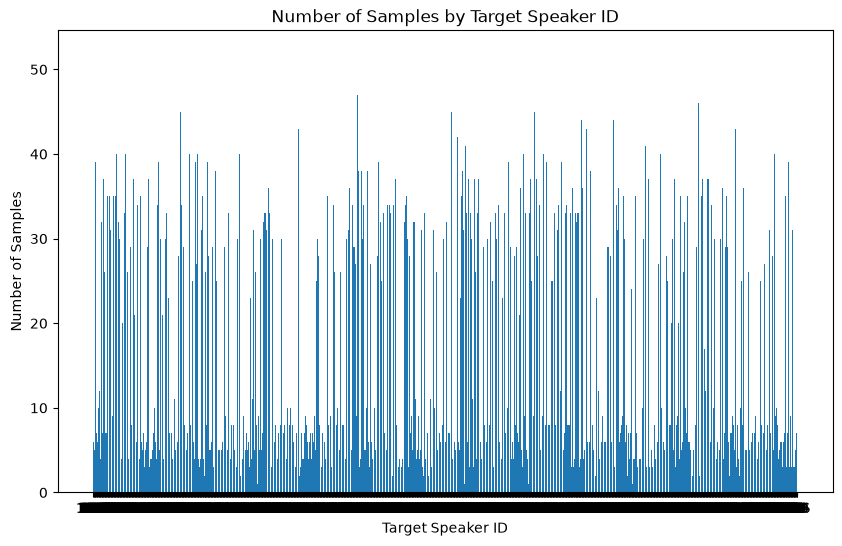

In [95]:
print(f"Number of samples: {len(D.df)}")
number_by_target_speaker = D.df.groupby('target_speaker').size().to_dict()
plt.figure(figsize=(10, 6))
plt.bar(number_by_target_speaker.keys(), number_by_target_speaker.values())
plt.xlabel('Target Speaker ID')
plt.ylabel('Number of Samples')
plt.title('Number of Samples by Target Speaker ID')
plt.show()

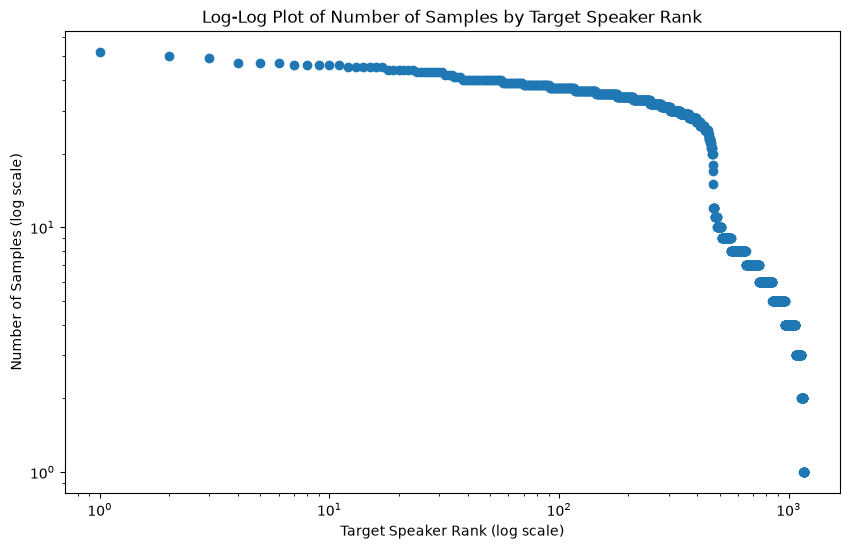

In [96]:
# log log plot of distribution of number of samples for target speaker rank
sorted_counts = sorted(number_by_target_speaker.items(), key=lambda x: x[1], reverse=True)
ranks = range(1, len(sorted_counts) + 1)
counts = [v for k, v in sorted_counts]
plt.figure(figsize=(10, 6))
plt.loglog(ranks, counts, marker='o', linestyle='None')
plt.xlabel('Target Speaker Rank (log scale)')
plt.ylabel('Number of Samples (log scale)')
plt.title('Log-Log Plot of Number of Samples by Target Speaker Rank')
plt.show()

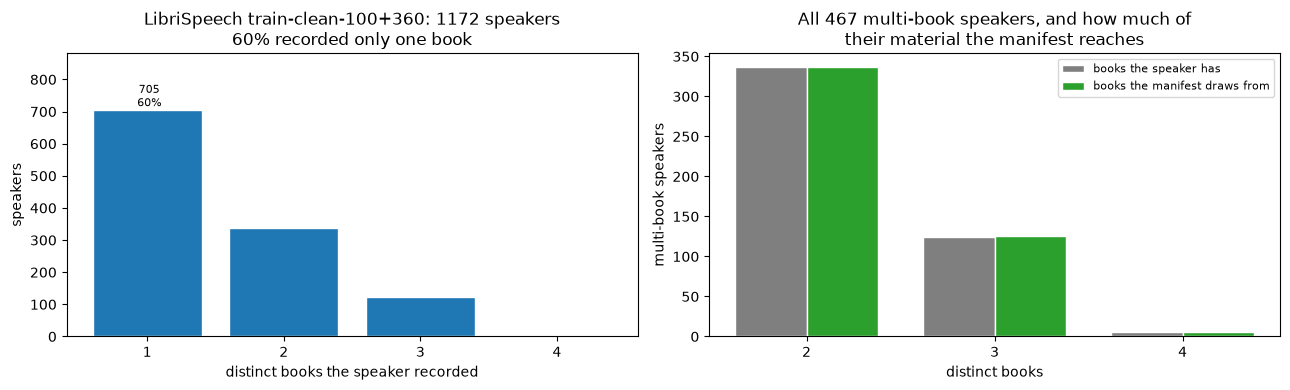

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

one book only  705/1172 (60.2%)
books used, mean 2.29 of 2.29 available


In [97]:
# check the book assignment for each speaker. The manifest should not draw from all books a speaker recorded, but only a subset of them. This is important for the target speaker extraction task, as it ensures that the model is tested on unseen books for each speaker.
# LibriSpeech ships one row per chapter: chapter | speaker | minutes | subset |  ... | book
present = D.df[D.df["target_absent"] == 0]
ch = []
for line in (ROOT / "data/librispeech/LibriSpeech/CHAPTERS.TXT").read_text(errors="replace").splitlines():
    if line.lstrip().startswith(";") or not line.strip():
        continue
    f = [p.strip() for p in line.split("|")]
    ch.append({"chapter": f[0], "speaker": f[1], "subset": f[3], "book": f[5]})
    
ch = pd.DataFrame(ch)

# only the subsets our splits were drawn from
ours = ch[ch["subset"].isin(["train-clean-100", "train-clean-360"])]
available = ours.groupby("speaker")["book"].nunique()

# how many books a speaker actually gets used for, as the mixture source.
# enrollment is excluded: B8 guarantees it is a different book, so counting it
# would add exactly 1 to every speaker and hide the real spread.
used = present.groupby("target_speaker")["target_chapter"].apply(
lambda c: c.map(dict(zip(ch["chapter"], ch["book"]))).nunique())

multi = available[available > 1].index
used_multi = used[used.index.isin(multi)]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

counts = available.value_counts().sort_index()
ax1.bar(counts.index, counts.values, color="tab:blue", edgecolor="white")
for x, v in counts.items():
    ax1.text(x, v, f" {v}\n {v/len(available):.0%}", ha="center", va="bottom",
    fontsize=8)
    ax1.set_xlabel("distinct books the speaker recorded")
    ax1.set_ylabel("speakers")
    ax1.set_xticks(counts.index)
    ax1.set_ylim(0, counts.max() * 1.25)
    ax1.set_title(f"LibriSpeech train-clean-100+360: {len(available)} speakers\n"
            f"{(available == 1).mean():.0%} recorded only one book")

    avail_multi = available[multi]
    w = 0.38
    xs = sorted(set(avail_multi) | set(used_multi))
    ax2.bar([x - w/2 for x in xs], [(avail_multi == k).sum() for k in xs], w,
            color="tab:grey", edgecolor="white", label="books the speaker has")
    ax2.bar([x + w/2 for x in xs], [(used_multi == k).sum() for k in xs], w,
            color="tab:green", edgecolor="white", label="books the manifest draws from")
    ax2.set_xlabel("distinct books")
    ax2.set_ylabel("multi-book speakers")
    ax2.set_xticks(xs)
    ax2.set_title(f"All {len(multi)} multi-book speakers, and how much of\n"
                f"their material the manifest reaches")
    ax2.legend(fontsize=8)

    plt.tight_layout()
    plt.show()

print(f"one book only  {(available==1).sum()}/{len(available)} "
    f"({(available==1).mean():.1%})")
print(f"books used, mean {used_multi.mean():.2f} of {avail_multi.mean():.2f} available")


## 2. Timing and overlap
### 2.1 `mixture_length_s`, `target_onset_s`, `interferer_onset_s`, `target_speech_s`, `target_activity`, `interferer_speech_s`, `interferer_activity`, `overlap_requested`, `overlap_achieved`

These columns are created using the following parameters to determine where the target will be speaking, for how long they will be speaking, where the interferer will speak, for how long will there be overlap between interefer and target:

- $\texttt{target\_activity\_ratio}: 0.75$ which is the goal for how long the target should ideally be speaking in the sample. This is the value that the paper $\textit{`REAL-TSE'}$ aimed for.
- $\texttt{activity\_tolerance}: 0.1$ how far above the goal the generator is allowed to land. Speech is built from WHOLE utterances, so there will be cases where we have longer speech so we have a range from 0.75-0.85 as a window. We will never consider lower.
- $\texttt{overlap\_ratio}: [0.2, 0.7]$ is drawn uniformly and represents the fraction of the window where both people are talking.
- $\texttt{overlap\_tolerance}: 0.03$ used for the interferer which is slid along the window to hit the requested overlap. 
- $\texttt{max\_utterances\_per\_source}: 8$ is the max number of consecutive utterances to make one speaker's speech, sp a source is never assembled from a long string of tiny fragments.

Therefore all of these columns are not independant draws and constrain each other arithmetically.


A big note, we only use one block to interfere with the target and not many places of interference. This does help simplify the train task, however, it does cost us realism. The hope is that these individual instances will translate to the many times we call on the model.

In [98]:
# only consider trials with a target speaker. Absent target trials have overlap 0 by definition
present = D.df[D.df['target_absent'] == 0]
print(f"Percentage of trials with a target speaker: {len(present)/len(D.df)*100:.2f}%")

Percentage of trials with a target speaker: 64.56%


#### Structural asymmetry

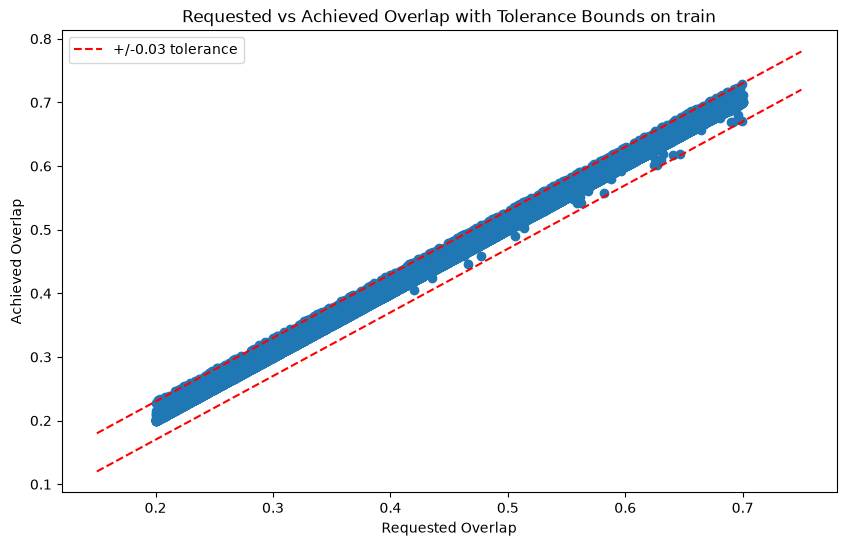

In [99]:
tolerance = D.cfg["overlap_tolerance"]
line = [0.15, 0.75]

plt.figure(figsize=(10, 6))
plt.scatter(present['overlap_requested'], present['overlap_achieved'])
plt.plot(line, [v + tolerance for v in line], color='red', linestyle='--', label=f'+/-{tolerance} tolerance')
plt.plot(line, [v - tolerance for v in line], color='red', linestyle='--')
plt.xlabel('Requested Overlap')
plt.ylabel('Achieved Overlap')
plt.title(f'Requested vs Achieved Overlap with Tolerance Bounds on {D.split}')
plt.legend()
plt.show()

In [100]:
miss = (present["overlap_achieved"] - present["overlap_requested"]).abs()
print(f"Worst miss: {miss.max():.4f}, Mean miss: {miss.mean():.4f}, Median miss: {miss.median():.4f}")
print(f"Acceptable hit percentages: {((miss <= tolerance).sum() / len(miss)) * 100:.2f}%")
print(f"Exact hit percentages: {((miss <= 1e-9).sum() / len(miss)) * 100:.2f}%")

Worst miss: 0.0300, Mean miss: 0.0040, Median miss: 0.0003
Acceptable hit percentages: 99.98%
Exact hit percentages: 8.76%


#### Activity, overlap and speech time

In [101]:
# activity 
difference = (present["target_activity"] - present["target_speech_s"]/ present["mixture_length_s"]).abs()
print(f"Worst activity difference: {difference.max():.4f}, Mean activity difference: {difference.mean():.4f}, Median activity difference: {difference.median():.4f}") 

Worst activity difference: 0.0001, Mean activity difference: 0.0000, Median activity difference: 0.0000


In [102]:
# speech time is sum of utterance durations
speech_time_diff = (present["target_speech_s"] - present["target_dur_list"].map(sum)).abs()
print(f"Worst speech time difference: {speech_time_diff.max():.4f}, Mean speech time difference: {speech_time_diff.mean():.4f}, Median speech time difference: {speech_time_diff.median():.4f}")  

Worst speech time difference: 0.0000, Mean speech time difference: 0.0000, Median speech time difference: 0.0000


In [103]:
# overlap is the shared time between two speaker talking intervals
worst = 0.0
for i, row in present.iterrows():
    shared_time = 0.0
    for t_start, t_end in spans(row, "target"):
        for i_start, i_end in spans(row, "interferer"):
            shared_time += max(0, min(t_end, i_end) - max(t_start, i_start))
    worst = max(worst, abs(shared_time / row["mixture_length_s"] - row["overlap_achieved"]))
print(f"Worst overlap difference: {worst:.4f}")

Worst overlap difference: 0.0001


Make a timeline plot for the first 3 trials with a target speaker, showing the target and interferer utterances as horizontal bars.

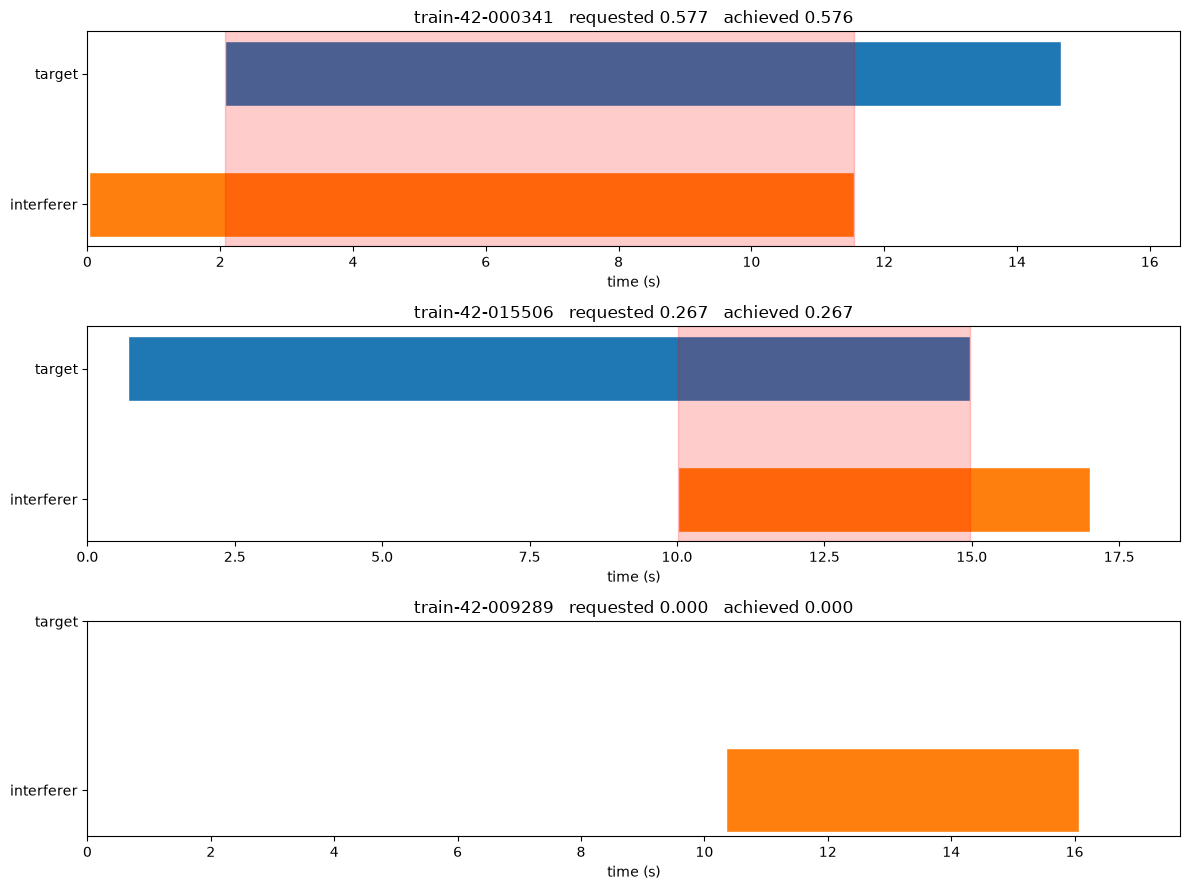

In [137]:
rows = 3
random_indices = np.random.choice(D.df.index, size=rows, replace=False)

fig, axes = plt.subplots(rows, 1, figsize=(12, 3 * rows))
if rows == 1:
    axes = [axes]

for i, ax in enumerate(axes):
    random_index = random_indices[i]
    row = D.df.iloc[random_index]

    # target bars on the top row, interferer underneath.
    # white edges so back-to-back utterances stay visible as separate blocks.
    for start, end in spans(row, "target"):
        ax.barh(1, end - start, left=start, height=0.5,
                color="tab:blue", edgecolor="white")
    for start, end in spans(row, "interferer"):
        ax.barh(0, end - start, left=start, height=0.5,
                color="tab:orange", edgecolor="white")

    # shade every stretch where both are talking
    for t_start, t_end in spans(row, "target"):
        for i_start, i_end in spans(row, "interferer"):
            lo, hi = max(t_start, i_start), min(t_end, i_end)
            if hi > lo:
                ax.axvspan(lo, hi, color="red", alpha=0.2)

    ax.set_xlim(0, row["mixture_length_s"])
    ax.set_yticks([0, 1])
    ax.set_yticklabels(["interferer", "target"])
    
    # Only label x-axis on the bottom plot to reduce clutter, or keep on all
    ax.set_xlabel("time (s)")
    ax.set_title(f"{row['trial_id']}   requested {row['overlap_requested']:.3f}   "
                 f"achieved {row['overlap_achieved']:.3f}")

plt.tight_layout()
plt.show()


### 3. Levels

#### `sir_db`, `snr_db`, `target_loudness_lufs` 
where the most notable thing is that the signal to interference ratio is always 0 dB when the target is absent. These features are controlled by the following parameter:
- $\texttt{clip\_ceiling}: 0.95$ which is responsible for the loudness of the target in the audio clip and is measured using BS.1770 as a loudness measure. 

Remember, a rendered trial consists of three audio segments: the target speaker, the interferer speaker, and the background noise. Each of these segments are mixed together, but we cannot assume that they will always be at the same level. To simplify our task, we define the target speaker's loudness using the LUFS (Loudness Units relative to Full Scale) standard, which we use as an anchor for the other segments. The signal-to-interference ratio (SIR) places the interferer relative to the target, and the signal-to-noise ratio (SNR) places the background noise relative to the target. A simple deduction is that the higher the db of the target, the easier the task.

**NOTE:** SIR and SNR effect the downstream ASR task differently NEGATIVELY and thus are two separate issues. These errors have different kind of errors in the output TEXT: 
- SIR: The louder this is, the more frequently we can expect insertions and substitutions of real words.
- SNR: This will cause more deletions and garbling where we can expect non-words and deletions.

We should use the SI-SDR metric to account for these damages as one unit.

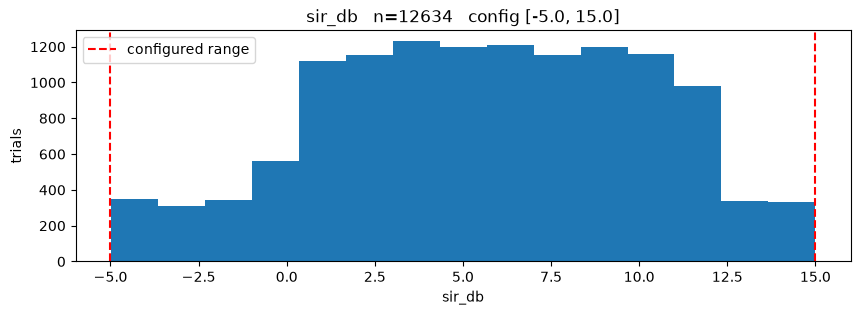

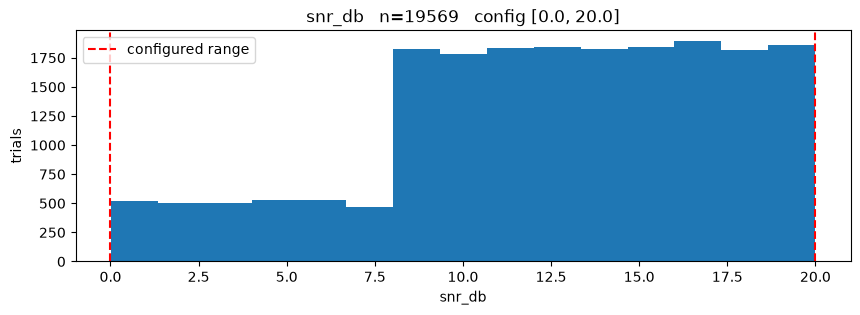

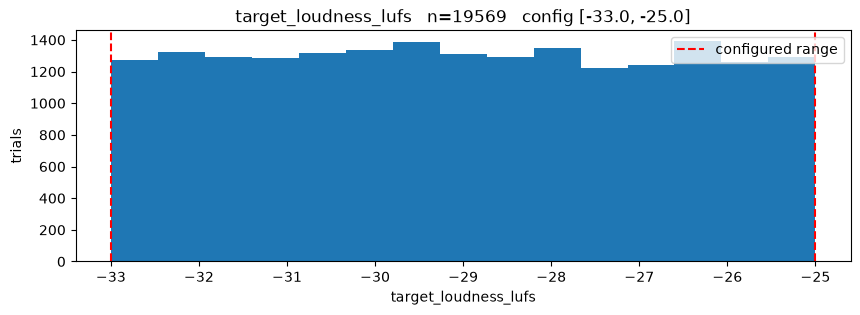

In [105]:
# does each level column cover the range the config asked for?
# no range= on the hist, so anything outside the configured range stays visible
for col in ["sir_db", "snr_db", "target_loudness_lufs"]:
    lo, hi = D.cfg[col]
    v = D.df[col].dropna()
    plt.figure(figsize=(10, 3))
    plt.hist(v, bins=15)
    plt.axvline(lo, color="red", linestyle="--")
    plt.axvline(hi, color="red", linestyle="--", label="configured range")
    plt.xlabel(col)
    plt.ylabel("trials")
    plt.title(f"{col}   n={len(v)}   config [{lo}, {hi}]")
    plt.legend()
    plt.show()


In [106]:
 # check independence
cols = ["sir_db", "snr_db", "target_loudness_lufs", "overlap_requested",
        "interferer_activity", "target_activity", "mixture_length_s", "t60_s"]
c = present[cols].corr()
floor = 2 / np.sqrt(len(present))

print(f"n = {len(present)}   noise floor |r| = {floor:.2f}")
print("pairs above the noise floor:")
for i in range(len(cols)):
    for j in range(i + 1, len(cols)):
        r = c.iloc[i, j]
        if abs(r) > floor:
            print(f"   {cols[i]:22} {cols[j]:22} r = {r:+.2f}")


n = 12634   noise floor |r| = 0.02
pairs above the noise floor:
   sir_db                 snr_db                 r = +0.04
   snr_db                 t60_s                  r = -0.11
   overlap_requested      interferer_activity    r = +0.95
   interferer_activity    target_activity        r = -0.09
   target_activity        mixture_length_s       r = -0.17
   mixture_length_s       t60_s                  r = -0.02


The pairs that must never appear are sir_db, snr_db, overlap_* and t60_s against each other. Those four are your experimental axes. If any two of them correlate, then "WER degrades as SIR falls" becomes unprovable — you can't tell whether it was the SIR or the thing riding along with it.


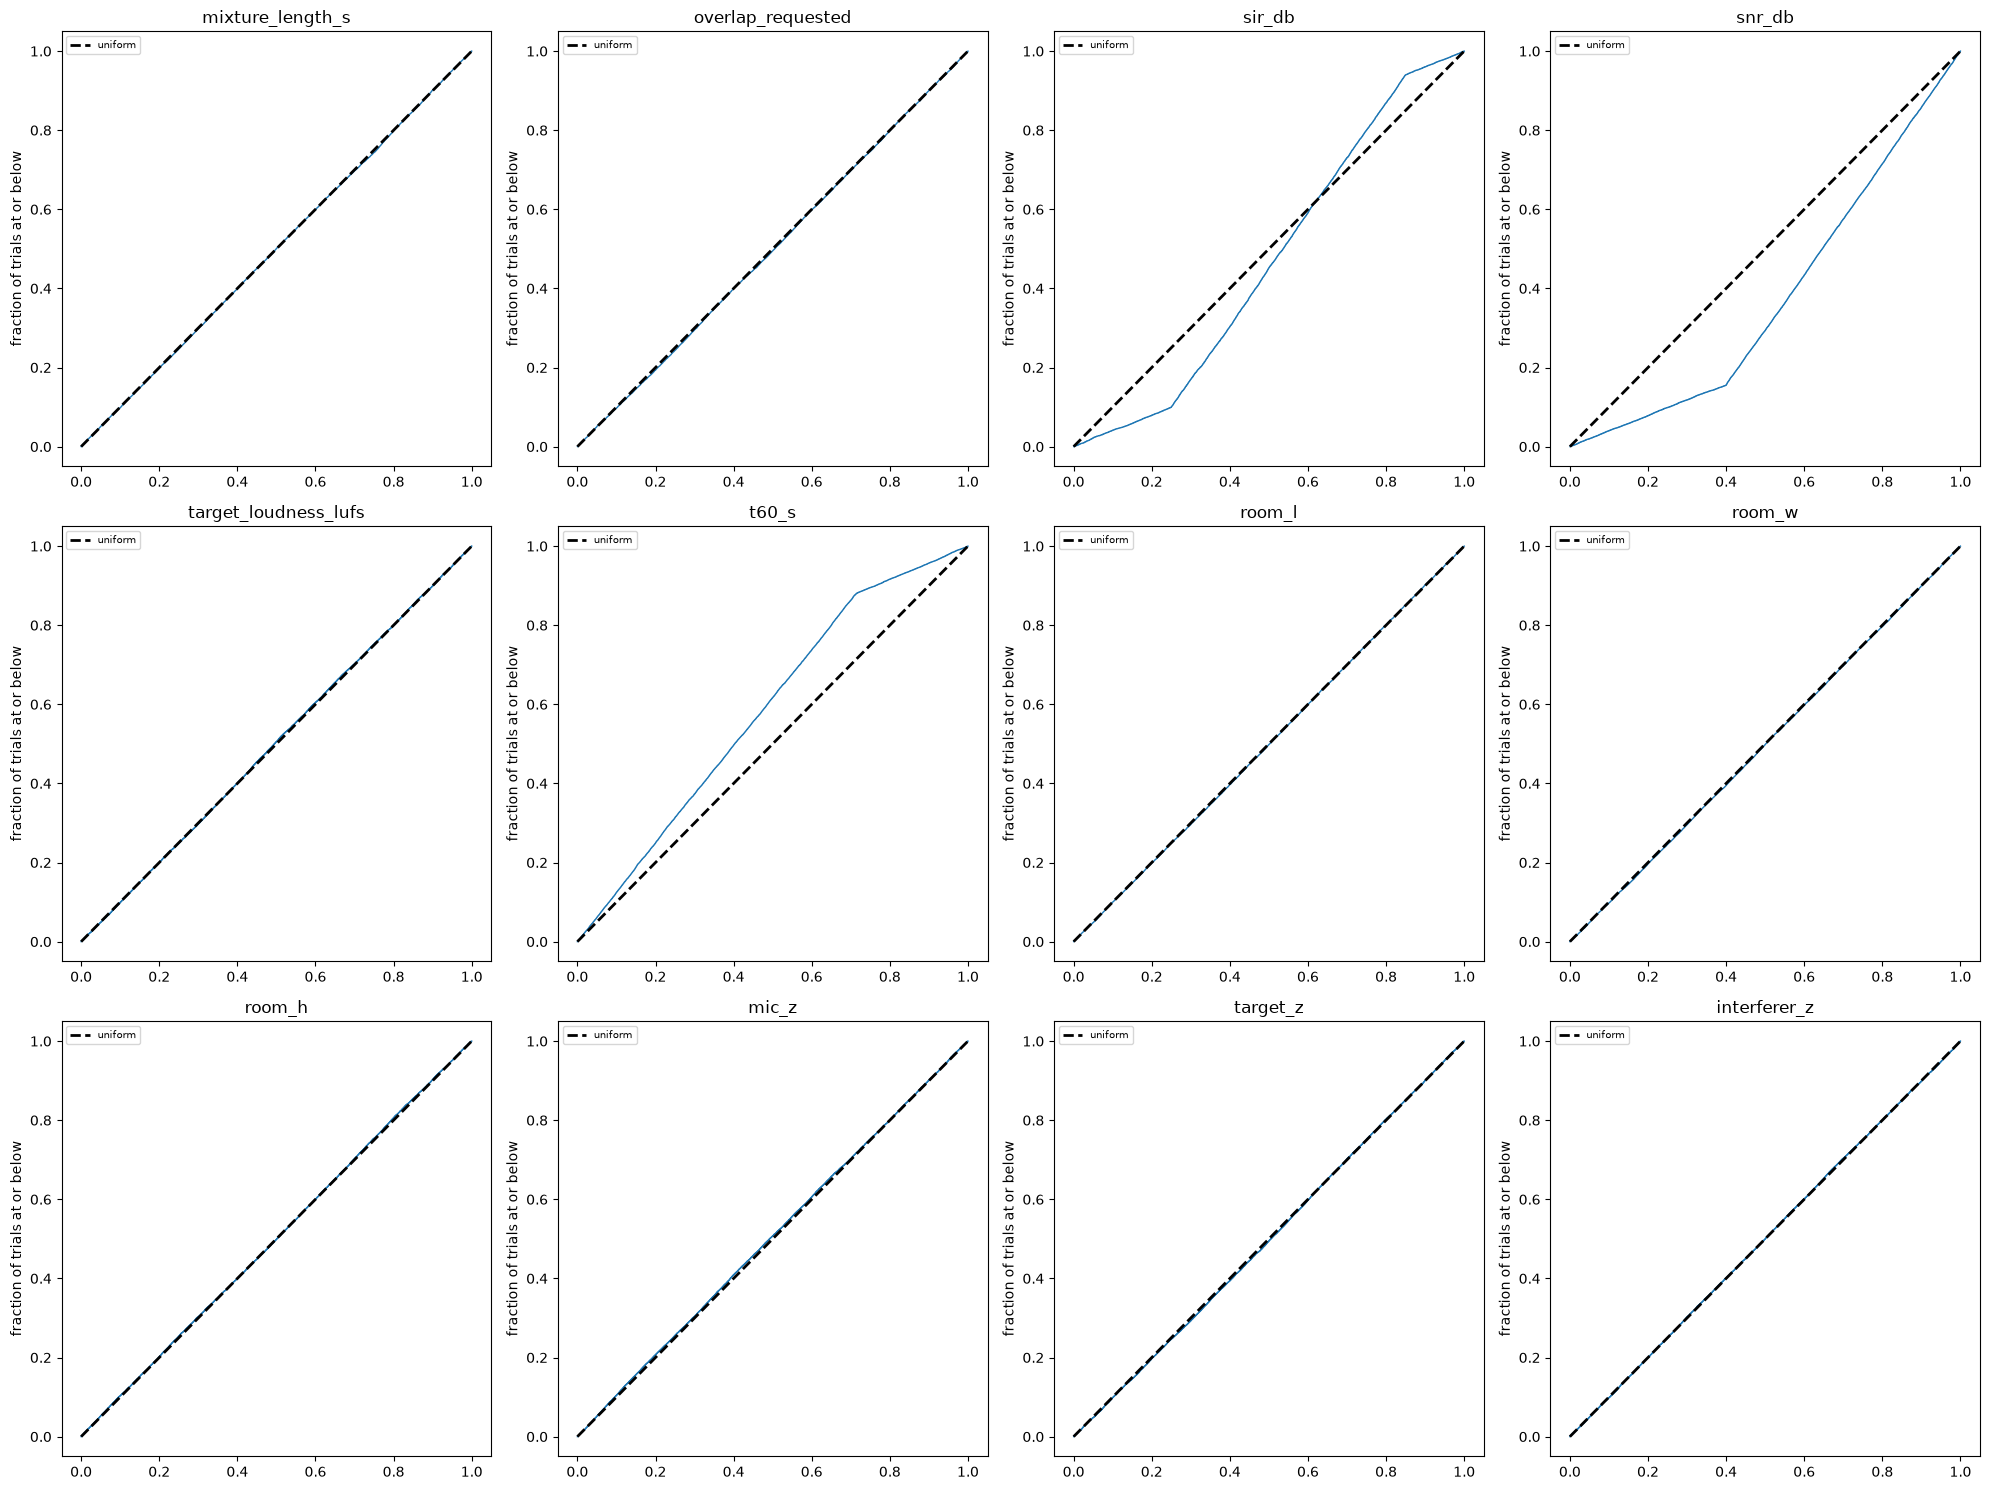

In [107]:
n = len(RANGES)
cols = min(n, 4)
rows = math.ceil(n / cols)

fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 5 * rows))
axes = np.atleast_1d(axes).flatten()

for ax, (col, key) in zip(axes, RANGES.items()):
    lo, hi = D.cfg[key]
    v = D.df[col][D.df["target_absent"] == 0] if col == "overlap_requested" else D.df[col]
    v = np.sort(v.dropna())
    
    ax.plot((v - lo) / (hi - lo), np.arange(1, len(v) + 1) / len(v), linewidth=1)
    ax.plot([0, 1], [0, 1], color="black", linestyle="--", linewidth=2, label="uniform")
    
    ax.set_ylabel("fraction of trials at or below")
    
    # Column name instead of the generic title
    ax.set_title(col) 
    ax.legend(fontsize=7)

# Hide any empty subplots in the grid
for i in range(n, len(axes)):
    axes[i].set_visible(False)

plt.tight_layout()
plt.show()

### 4. Room and reverberation


4.1 There are 13 independent room features that contribute to this audio setup. These variables include:
- `t60_s` is the time it takes for a room's echoes to decay by 60dB which I sample from [0.15, 0.6].
- `room_l/w/h`
- `mic_x/y/z`
- `target_x/y/z`
- `interferer_x/y/z`

which describe a shoebox room which is built with the $\texttt{pyroomacoustics}$ library. We place the mic and two sources at the given coordinates, set wall absorbtion so that the delay time from doppler effect is the `t60_s` value, and generate one room impulse response per source. We also make reverb to make the audio sound like a room rather than a recording booth. The most important thing is that ALL SPEAKERS IN A SAMPLE MUST BE IN THE SAME ROOM!

The procedure per source:
1. Draw a horizontal distance from the mic — source_distance_m: [0.66, 2.0] m, uniform.
2. Draw an azimuth uniformly over the full circle, 0 to 2π.
3. Convert to x/y by trigonometry around the mic: x = mic_x + d·cos(az), y = mic_y + d·sin(az).
4. Reject and redraw if the point lands within 0.3 m of any wall — up to 50 attempts, then raise.
5. Draw z independently from source_height_m: [0.9, 1.8] m. This is a separate draw, not derived from the distance.

The mic itself is placed first, in sample_room (lines 146–148): x and y uniform over the central 35–65% of each room dimension, z
from mic_height_m: [0.9, 1.8]. So the mic is always roughly central and the sources orbit it.


Distribution of t60_s


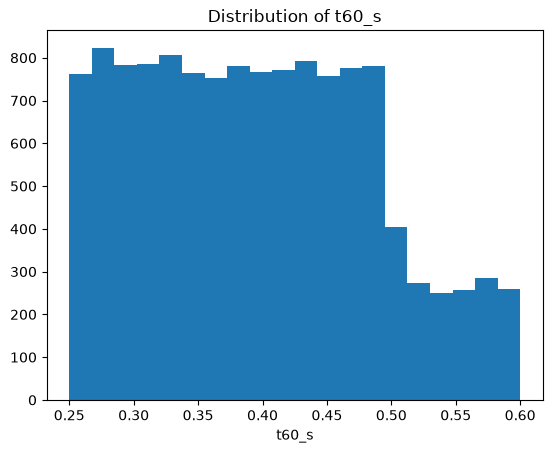

Number of trials with t60_s above 0.3s latency budget: 10380 (82.16%)


In [108]:
print(f"Distribution of t60_s")
plt.hist(present["t60_s"], bins=20)
plt.title(f"Distribution of t60_s")
plt.xlabel("t60_s")
plt.show()

num_t_above_latency_budget = (present["t60_s"] > 0.3).sum()
print(f"Number of trials with t60_s above 0.3s latency budget: {num_t_above_latency_budget} "
      f"({num_t_above_latency_budget / len(present) * 100:.2f}%)")

**IDEA:** That is not a bug in the data. If your reference is direct + early 50 ms, the model is being trained to suppress a tail extending up to 600 ms into the future - from a 300 ms window. Either the task is partly ill-posed, or the model learns a **statistical prior over rooms** rather than actually cancelling the tail it can't see.

In [109]:
# geometry invariants -- all recomputed from the coordinates that were recorded
df = D.df
lo, hi = D.cfg["source_distance_m"]

for speaker in ["target", "interferer"]:
    dist = np.sqrt((df[f"{speaker}_x"] - df["mic_x"])**2 + (df[f"{speaker}_y"] - df["mic_y"])**2)
    
    # clearance to the nearest of the four walls
    wall = pd.concat([df[f"{speaker}_x"], df["room_l"] - df[f"{speaker}_x"], df[f"{speaker}_y"], df["room_w"] - df[f"{speaker}_y"]], axis=1).min(axis=1)
    print(f"{speaker:11} distance {dist.min():.2f}..{dist.max():.2f} m "
        f"(config [{lo}, {hi}])   min wall clearance {wall.min():.2f} m (rule 0.3)")
        
    assert (dist >= lo - 0.01).all() and (dist <= hi + 0.01).all()
    assert (wall >= 0.3 - 1e-6).all() # I needed to put in the small fudge factor because the generator sometimes draws a source at exactly 0.3 m from a wall, and the float representation then fails the assert
    assert (df[f"{speaker}_z"] < df["room_h"]).all()

# T60 must be physically reachable in the room it was drawn for
vol = df["room_l"] * df["room_w"] * df["room_h"]
surf = 2 * (df["room_l"] * df["room_w"] + df["room_l"] * df["room_h"]
            + df["room_w"] * df["room_h"])
assert (df["t60_s"] >= 0.161 * vol / surf).all(), "T60 below the Sabine floor"

# the mic sits centrally by construction, never against a wall
print(f"mic at {(df['mic_x']/df['room_l']).min():.2f}.."
    f"{(df['mic_x']/df['room_l']).max():.2f} of room length (rule 0.35-0.65)")

print(f"\nT60 above the 0.3 s latency budget in {(df['t60_s'] > 0.3).mean():.0%} of trials")


target      distance 0.66..2.00 m (config [0.66, 2.0])   min wall clearance 0.31 m (rule 0.3)
interferer  distance 0.66..2.00 m (config [0.66, 2.0])   min wall clearance 0.31 m (rule 0.3)
mic at 0.35..0.65 of room length (rule 0.35-0.65)

T60 above the 0.3 s latency budget in 82% of trials


Distances come back at exactly 0.66..2.00 for both sources, and the mic sits at 0.35–0.65 of the room length. These confirm the recorded coordinates actually reproduce the sampling rules, rather than just trusting the generator. The finding that most matters is that the latency budget that we aim for of 200ms-300ms for target separation has 67% of the trials already exceding the budget. This requires a decision because we essentially have the following problem: the reference signal is the direct sound, which in its purest form after hitting the walls comes out to 50ms if it is a PURE signal and no reverb. Secondly, we have the budget to allow processing of this signal over 200-300ms, which means at BEST our model will only listen to 300ms of audio before being able to separate out the target speaker. However, we are sampling our T60, which is our parameter for controlling the amount of reverb, which can go all the way up to 600ms before all the sound has gotten to the speaker. So we essentially 300 more ms of signal contained within that audio stream that we are NOT allowed to see within that latency budget.

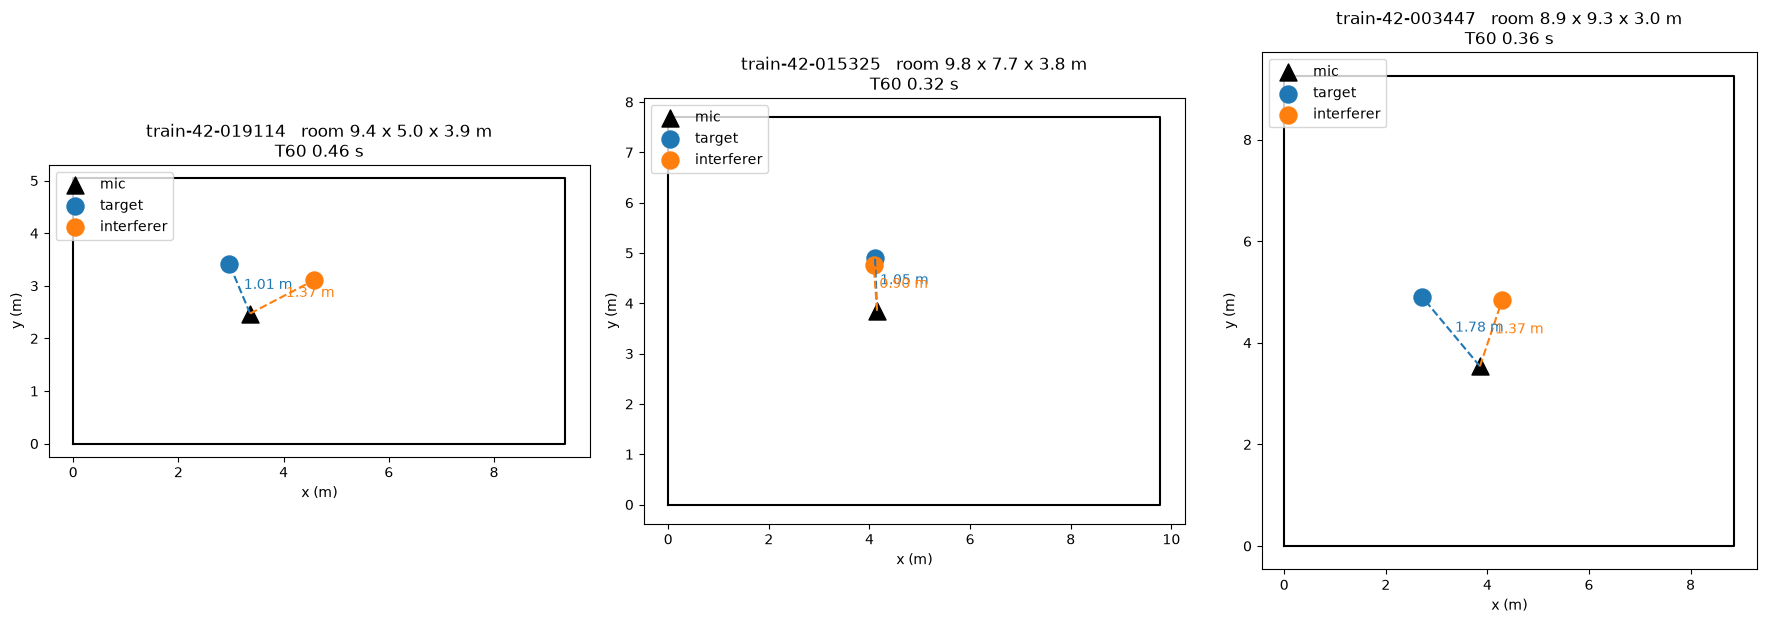

In [ ]:
n_plots = len(random_indices)
fig, axes = plt.subplots(1, n_plots, figsize=(6 * n_plots, 6))

# Ensure axes is iterable in case there is only 1 index
if n_plots == 1:
    axes = [axes]

for ax, i in zip(axes, random_indices):
    row = D.df.iloc[i]

    # Draw room boundaries
    ax.plot([0, row["room_l"], row["room_l"], 0, 0],
            [0, 0, row["room_w"], row["room_w"], 0], color="black")
    
    # Plot entities
    ax.scatter(row["mic_x"], row["mic_y"], marker="^", s=150, color="black", label="mic")
    ax.scatter(row["target_x"], row["target_y"], s=150, color="tab:blue", label="target")
    ax.scatter(row["interferer_x"], row["interferer_y"], s=150, color="tab:orange", label="interferer")

    # Dashed lines to the mic, labelled with the distance
    for who, colour in [("target", "tab:blue"), ("interferer", "tab:orange")]:
        ax.plot([row["mic_x"], row[f"{who}_x"]], [row["mic_y"], row[f"{who}_y"]],
                color=colour, linestyle="--")
        
        d = ((row[f"{who}_x"] - row["mic_x"])**2 + (row[f"{who}_y"] - row["mic_y"])**2) ** 0.5
        
        ax.text((row["mic_x"] + row[f"{who}_x"]) / 2,
                (row["mic_y"] + row[f"{who}_y"]) / 2, f" {d:.2f} m", color=colour)

    # Apply axis-level formatting outside the inner loop
    ax.set_aspect("equal")
    ax.set_xlabel("x (m)")
    ax.set_ylabel("y (m)")
    
    # Added a newline in the title so it doesn't overlap adjacent plots
    ax.set_title(f"{row['trial_id']}   room {row['room_l']:.1f} x {row['room_w']:.1f} x "
                 f"{row['room_h']:.1f} m\nT60 {row['t60_s']:.2f} s")
    ax.legend(loc="upper left")

plt.tight_layout()
plt.show()

We want to check that the activity level of both the interferer and the target can be roughly the same. This is so that our model doesnt just guess one over the other based on duration and not on voice qualities.

In [111]:
absent = D.df[D.df["target_absent"] == 1]
present = D.df[D.df["target_absent"] == 0]

cols = ["t60_s", "snr_db", "target_loudness_lufs", "mixture_length_s",
        "room_l", "room_w", "room_h", "interferer_activity", "interferer_speech_s"]
print(f"{'column':22} {'present':>9} {'absent':>9} {'gap/sd':>8}")
for col in cols:
    sd = D.df[col].std()
    gap = (absent[col].mean() - present[col].mean()) / sd
    print(f"{col:22} {present[col].mean():9.2f} {absent[col].mean():9.2f} {gap:+8.2f}")



column                   present    absent   gap/sd
t60_s                       0.40      0.40    +0.01
snr_db                     12.47     12.45    -0.00
target_loudness_lufs      -29.03    -28.96    +0.03
mixture_length_s           17.52     17.48    -0.03
room_l                      7.50      7.52    +0.01
room_w                      7.52      7.50    -0.01
room_h                      3.50      3.50    -0.01
interferer_activity         0.57      0.63    +0.40
interferer_speech_s         9.98     11.05    +0.37


Anything past about 1 sd is a giveaway worth chasing.

In [112]:
# 4.4  is T60 physically reachable, and did the rejection loop bend anything?
vol = D.df["room_l"] * D.df["room_w"] * D.df["room_h"]
surf = 2 * (D.df["room_l"] * D.df["room_w"] + D.df["room_l"] * D.df["room_h"] + D.df["room_w"] * D.df["room_h"])
# Sabine's equation, T60 = 0.161V / (S*alpha), at alpha = 1 -- the shortest T60
# this room could physically have, since a wall cannot absorb more than all the
# sound hitting it. Sabine (1922), "Collected Papers on Acoustics"; the same
# relation pra.inverse_sabine inverts in build_manifest.py. "Sabine floor" is
# our label for the alpha = 1 case, not a standard term.
sabine_floor = 0.161 * vol / surf

print(f"room volume {vol.min():.0f}..{vol.max():.0f} m3")
print(f"sabine floor on T60 {sabine_floor.min():.3f}..{sabine_floor.max():.3f} s")
print(f"config asks from {D.cfg['t60_s'][0]} s -- infeasible in the larger rooms")
print(f"trials below the floor: {(D.df['t60_s'] < sabine_floor).sum()} (must be 0)")

# the rejection loop could bias t60 towards small rooms. quartiles are a far better test of that than a correlation at this sample size.
lo, hi = D.cfg["t60_s"]
print(f"\nt60 quartiles  {np.percentile(D.df['t60_s'], [0,25,50,75,100]).round(3)}")
print(f"uniform gives  {np.percentile(np.linspace(lo,hi,10000), [0,25,50,75,100]).round(3)}")
print(f"corr(t60, volume) = {np.corrcoef(D.df['t60_s'], vol)[0,1]:+.3f}"
    f"   noise floor {2/np.sqrt(len(D.df)):.3f}")



room volume 77..395 m3
sabine floor on T60 0.111..0.178 s
config asks from 0.25 s -- infeasible in the larger rooms
trials below the floor: 0 (must be 0)

t60 quartiles  [0.25  0.32  0.391 0.464 0.6  ]
uniform gives  [0.25  0.337 0.425 0.512 0.6  ]
corr(t60, volume) = -0.008   noise floor 0.014


We want to check whether the T60 values were pushed towards small rooms due to the mathematical impossibilities of the low T60 in a large room. We want to check that our generator is NOT making these mistakes. We are making sure that we are redrawing our samples from an entirely new room instead of just resampling the T60 inside of a fixed room. The idea comes from my rejection sampler. My biggest room has a sabine floor score of 0.178. and some T60s are from 0.15s. So it is impossible to have such a low T60. We are just checking that 1. Our t60 and volume are not correlated as this would mean that we are pushing the t60 value away from uniform when rejection sampling, and 2. we are checking that the correlation just doesnt excede the noise floor, which is the highest we are willing to accept before the correlation becomes a statistically significant result.

In [113]:
#4.5  the configured distance is horizontal; the true 3-D distance differs
for who in ["target", "interferer"]:
    horiz = np.sqrt((D.df[f"{who}_x"] - D.df["mic_x"])**2 + (D.df[f"{who}_y"] - D.df["mic_y"])**2)
    true3d = np.sqrt(horiz**2 + (D.df[f"{who}_z"] - D.df["mic_z"])**2)
    print(f"{who:11} horizontal {horiz.min():.2f}..{horiz.max():.2f}, "  
        f"true 3-D {true3d.min():.2f}..{true3d.max():.2f}   "
        f"config {D.cfg['source_distance_m']}")

# in mono there is no spatial cue, so two speakers standing close is harmless
sep = np.sqrt((D.df["target_x"] - D.df["interferer_x"])**2 + (D.df["target_y"] - D.df["interferer_y"])**2)
print(f"speaker separation {sep.min():.2f}..{sep.max():.2f} m, "
    f"under 0.5 m in {(sep < 0.5).sum()} trials") 

target      horizontal 0.66..2.00, true 3-D 0.66..2.14   config [0.66, 2.0]
interferer  horizontal 0.66..2.00, true 3-D 0.66..2.18   config [0.66, 2.0]
speaker separation 0.01..3.92 m, under 0.5 m in 1889 trials


We use the above check to see the horizontal versus true 3-D distance of the target and interferer speakers relative to the microphone. The horizontal distance is calculated using the x and y coordinates, while the true 3-D distance also takes into account the z-coordinate (height) of the speakers and microphone. We can see that generally the speakers are actually in 3D space up to 4m away from each other in 3D space.

### 5. Enrollment and pairing
5.1 Enrollment criteria are combined to ensure that the only way to complete the task is by actually listening to the voice. The following variables act as a safe guard against finding features that the model can leverage that will prevent it from learning things that are not the voice of the target (and to prioritise it).

- `enrollment_utt`
- `enrollment_offset_s`
- `enrollment_length_s`
- `enrollment_eq`
- `target_speaker`
- `interferer_speaker`
- `target_chapter`
- `interferer_chapter`
- `same_gender`

In [114]:
# LibriSpeech metadata: which speaker is which sex, which chapter is which book
ls = ROOT / "data/librispeech/LibriSpeech"
sex, book = {}, {}
for line in (ls / "SPEAKERS.TXT").read_text(errors="replace").splitlines():
    if line.lstrip().startswith(";") or not line.strip():
        continue
    f = [p.strip() for p in line.split("|")]
    sex[f[0]] = f[1]
for line in (ls / "CHAPTERS.TXT").read_text(errors="replace").splitlines():
    if line.lstrip().startswith(";") or not line.strip():
        continue
    f = [p.strip() for p in line.split("|")]
    book[f[0]] = f[5]

present = D.df[D.df["target_absent"] == 0]
target_book = present["target_chapter"].map(book)
enroll_chapter = present["enrollment_utt"].str.split("-").str[1]

print(f"target != interferer         "
    f"{(D.df['target_speaker'] != D.df['interferer_speaker']).all()}")
print(f"different books               "
    f"{(target_book != present['interferer_chapter'].map(book)).all()}")
print(f"enrollment chapter differs    {(enroll_chapter != present['target_chapter']).all()}")
print(f"enrollment BOOK differs       {(enroll_chapter.map(book) != target_book).all()}"
    f"   same book in {(enroll_chapter.map(book) == target_book).sum()} trials")

# same_gender must agree with the actual metadata, not just the intended rate
actual = (D.df["target_speaker"].map(sex) == D.df["interferer_speaker"].map(sex))
print(f"same_gender flag is truthful  {(D.df['same_gender'] == actual.astype(int)).all()}")

# the enrollment window must fit inside its clip
edur = D.df["enrollment_utt"].map(D.utts["duration"].to_dict())
print(f"enrollment window fits        "
    f"{((D.df['enrollment_offset_s'] + D.df['enrollment_length_s']) <= edur + 1e-6).all()}")
print(f"enrollment clips all >= 5 s   {(edur >= D.df['enrollment_length_s']).all()}")


target != interferer         True
different books               True
enrollment chapter differs    True
enrollment BOOK differs       True   same book in 0 trials
same_gender flag is truthful  True
enrollment window fits        True
enrollment clips all >= 5 s   True


In [115]:
# is the enrollment offset uniform in the room available to it? We want to check if the enrollment offset is uniformly distributed within the available room of the enrollment clip. The available room is calculated as the duration of the enrollment utterance minus the length of the enrollment segment. We then compute the fraction of the enrollment offset relative to this available room and check its mean value. A uniform distribution would have a mean of 0.5.
edur = D.df["enrollment_utt"].map(D.utts["duration"].to_dict())
room = edur - D.df["enrollment_length_s"]

print(f"\noffset as fraction of available room: mean "
    f"{(D.df['enrollment_offset_s'] / room).mean():.3f} (uniform -> 0.500)")


offset as fraction of available room: mean 0.497 (uniform -> 0.500)


In [116]:
# speaker usage balance, target and interferer. We want to check if the generator is over-using a few speakers and under-using others.
print(f"target usage:     {D.df['target_speaker'].nunique()} distinct, "
    f"{D.df['target_speaker'].value_counts().min()}.."
    f"{D.df['target_speaker'].value_counts().max()} trials each")
print(f"interferer usage: {D.df['interferer_speaker'].nunique()} distinct, "
    f"{D.df['interferer_speaker'].value_counts().min()}.."
    f"{D.df['interferer_speaker'].value_counts().max()} trials each")


target usage:     1170 distinct, 1..52 trials each
interferer usage: 1172 distinct, 3..32 trials each


### 6. Noise

#### 6.1 Check that the noise bed level is within the configured range
- `noise_clip`
- `noise_offset_s`

In [117]:
# every clip named must exist in the index for this split's noise set
known = set(D.noise.index)
missing = set(D.df["noise_clip"]) - known
print(f"noise split '{D.cfg['noise_split']}': {len(known)} clips in the index")
print(f"clips named by the manifest but absent from that index: {len(missing)}\n")

#  no clip may be shared between a training and an evaluation manifest.               
train_clips = set(load("smoke_train").df["noise_clip"])
val_clips = set(load("smoke_val").df["noise_clip"])
print(f"clips shared between smoke_train and smoke_val: {len(train_clips & val_clips)}\n")

# is there enough noise left in the clip to cover the mixture?
clipdur = D.df["noise_clip"].map(D.noise["duration"].to_dict())
remaining = clipdur - D.df["noise_offset_s"]
print(f"\nclip durations {clipdur.min():.1f}..{clipdur.max():.1f} s "
    f"(median {clipdur.median():.1f})")
print(f"mixtures       {D.df['mixture_length_s'].min():.1f}.."
    f"{D.df['mixture_length_s'].max():.1f} s")
print(f"trials needing more noise than the clip has left: "
    f"{(remaining < D.df['mixture_length_s']).sum()}/{len(D.df)}")
print(f"trials where the whole clip is shorter than the mixture: "
    f"{(clipdur < D.df['mixture_length_s']).sum()}/{len(D.df)}\n")

# how much of the library would survive a "long enough clips only" rule?
d = D.noise["duration"]
for t in [15.0, 20.0]:
    print(f"clips >= {t:4.1f} s: {(d >= t).sum():5} of {len(d)} ({(d >= t).mean():.2%})")


noise split 'tr': 20000 clips in the index
clips named by the manifest but absent from that index: 0

clips shared between smoke_train and smoke_val: 0


clip durations 3.4..47.6 s (median 10.0)
mixtures       15.0..20.0 s
trials needing more noise than the clip has left: 19510/19569
trials where the whole clip is shorter than the mixture: 19066/19569

clips >= 15.0 s:  1462 of 20000 (7.31%)
clips >= 20.0 s:    86 of 20000 (0.43%)


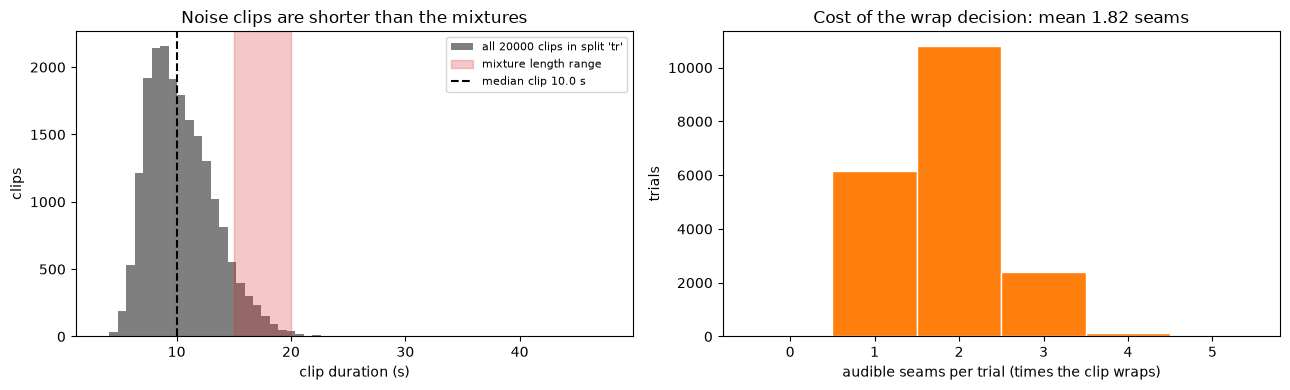

In [118]:
clipdur = D.df["noise_clip"].map(D.noise["duration"].to_dict())
# how many times the read pointer crosses the end of the clip
seams = np.floor((D.df["noise_offset_s"] + D.df["mixture_length_s"]) / clipdur)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

ax1.hist(D.noise["duration"], bins=60, color="tab:grey",
        label=f"all {len(D.noise)} clips in split '{D.cfg['noise_split']}'")
ax1.axvspan(D.df["mixture_length_s"].min(), D.df["mixture_length_s"].max(),
            color="tab:red", alpha=0.25, label="mixture length range")
ax1.axvline(D.noise["duration"].median(), color="black", linestyle="--",
            label=f"median clip {D.noise['duration'].median():.1f} s")
ax1.set_xlabel("clip duration (s)")
ax1.set_ylabel("clips")
ax1.set_title("Noise clips are shorter than the mixtures")
ax1.legend(fontsize=8)

ax2.hist(seams, bins=np.arange(-0.5, seams.max() + 1.5), color="tab:orange",
        edgecolor="white")
ax2.set_xlabel("audible seams per trial (times the clip wraps)")
ax2.set_ylabel("trials")
ax2.set_xticks(range(int(seams.max()) + 1))
ax2.set_title(f"Cost of the wrap decision: mean {seams.mean():.2f} seams")

plt.tight_layout()
plt.show()


### 7. Target-absent trials

The behaviour being trained here is *saying nothing*. A model trained only on trials where the target speaks learns "always emit a voice", because nothing in the loss ever rewards silence. Handed a mixture where the target never speaks, it does the only thing it knows and outputs the interferer. The judge transcribes the interferer's words, and by the metric every one of them is a hallucination — words attributed to a speaker who said nothing.

So `target_absent: 1` is a complete trial, not a missing row: a real enrolled speaker, a real interferer, a real room, and no target speech. CARTSE uses ~38% (Li & Seki, 2026); the configured 0.35 is in line with that.

Three things have to hold, and the third is the one that matters:

1. an absent row is internally consistent — the target fields are empty, everything else intact;
2. the achieved rate is the rate that was asked for;
3. **absence is not predictable from anything except the audio.** Any column that separates absent from present lets the model decide when to go quiet without ever consulting the enrollment.

#### 7.1  What an absent row keeps and what it drops

In [119]:
# --- 7.1  what an absent row still carries, and what it drops
absent = D.df[D.df["target_absent"] == 1]
present = D.df[D.df["target_absent"] == 0]
print(f"{D.split}: {len(absent)} absent, {len(present)} present\n")

print("dropped -- nothing to describe, so the field is empty")
for col in ["target_chapter", "target_utts", "target_onsets_s", "sir_db"]:
    print(f"  {col:22} null in {absent[col].isna().sum():5}/{len(absent)} absent, "
          f"{present[col].isna().sum():5}/{len(present)} present")




train: 6935 absent, 12634 present

dropped -- nothing to describe, so the field is empty
  target_chapter         null in  6935/6935 absent,     0/12634 present
  target_utts            null in  6935/6935 absent,     0/12634 present
  target_onsets_s        null in  6935/6935 absent,     0/12634 present
  sir_db                 null in  6935/6935 absent,     0/12634 present


We are checking in the above that the absent trials have null values for the target-related columns, as expected, We want the null score for each of the target-related columns in all absent trials.

In [120]:
print("\nzeroed -- a real measurement that happens to be zero")
for col in ["target_speech_s", "target_activity",
            "overlap_requested", "overlap_achieved"]:
    print(f"  {col:22} {absent[col].min():.1f}..{absent[col].max():.1f}")




zeroed -- a real measurement that happens to be zero
  target_speech_s        0.0..0.0
  target_activity        0.0..0.0
  overlap_requested      0.0..0.0
  overlap_achieved       0.0..0.0


The above is checking that we have float fields and values for the zeroed columns so that we do NOT have NaN values in the absent trials. 

In [121]:
print("\nkept -- an absent trial is a whole trial, not a truncated one")
print(f"  enrollment speaker is the target  "
      f"{(absent['enrollment_utt'].str.split('-').str[0] == absent['target_speaker']).all()}")
print(f"  enrollment is never the interferer "
      f"{not (absent['enrollment_utt'].str.split('-').str[0] == absent['interferer_speaker']).any()}")
print(f"  distinct enrollment clips         {absent['enrollment_utt'].nunique()}/{len(absent)}")
print(f"  the target still has a position   "
      f"{absent[['target_x', 'target_y', 'target_z']].notna().all().all()}")


kept -- an absent trial is a whole trial, not a truncated one
  enrollment speaker is the target  True
  enrollment is never the interferer True
  distinct enrollment clips         6752/6935
  the target still has a position   True


The above check is used to confirm that even when the target is absent, the enrollment speaker is still the target, and the interferer is never the enrollment speaker. 

In [122]:
# sampled, then unused: there is no target signal to normalise to this loudness.
# The renderer must not silently apply it to the interferer instead.
print(f"\n  target_loudness_lufs is still drawn: "
      f"{absent['target_loudness_lufs'].min():.1f}.."
      f"{absent['target_loudness_lufs'].max():.1f} LUFS -- dead on these rows")


  target_loudness_lufs is still drawn: -33.0..-25.0 LUFS -- dead on these rows


The above check shows that the generator is still generating target loudness values even for absent trials, which is not really a problem but something to take note of. We must just make sure that we are using the intereferer as the reference point.

`target_loudness_lufs` is drawn on absent rows but has nothing to normalise. Harmless in the manifest, a trap in the renderer: applying it to the interferer instead would make absent mixtures a fixed loudness and hand the model the answer. The renderer must ignore it when `target_absent` is 1.

#### 7.2  Does the achieved rate match the configured rate?

In [123]:
# did the requested absent fraction survive the generator?
def intended_absent(trial_id, fraction):
    # `aug` is child 3. build_manifest.py now spawns FIVE children (the fifth
    # draws the regime, B12 PR2), but SeedSequence.spawn(n) is deterministic
    # per index -- spawn(5)[3] is the same stream as spawn(4)[3] -- so this
    # replay is unaffected by that change. Spawning 5 here documents the match.
    digest = hashlib.blake2b(trial_id.encode(), digest_size=8).digest()
    seeds = np.random.SeedSequence(int.from_bytes(digest, "big")).spawn(5)
    return float(np.random.default_rng(seeds[3]).random()) < fraction


for split in ["train", "val", "smoke_train", "smoke_val"]:
    S = load(split)
    frac = S.cfg["target_absent_fraction"]
    kept = S.df["trial_id"].map(lambda t: intended_absent(t, frac)).astype(int)
    assert (kept == S.df["target_absent"]).all(), f"{split}: replay disagrees"

    failed_file = S.path.with_suffix(".failed.txt")
    dropped = failed_file.read_text().split() if failed_file.exists() else []
    dropped_absent = sum(intended_absent(t, frac) for t in dropped)
    rate = (S.df["target_absent"] == 1).mean()

    print(f"{split:12} asked {frac:.2f}  got {rate:.3f}  ({len(S.df)} trials)")
    print(f"{'':12} dropped {len(dropped):4}:  {dropped_absent} absent, "
          f"{len(dropped) - dropped_absent} present")


train        asked 0.35  got 0.354  (19569 trials)
             dropped  431:  0 absent, 431 present
val          asked 0.35  got 0.382  (199 trials)
             dropped    1:  0 absent, 1 present
smoke_train  asked 0.35  got 0.280  (50 trials)
             dropped    0:  0 absent, 0 present
smoke_val    asked 0.35  got 0.700  (20 trials)
             dropped    0:  0 absent, 0 present


The above is validating that we have the correct number of absent trials in the datasets. These values indicate that we have slighlty more absent trials than expected in train and val but it is neglible and something to report in my paper.

#### 7.3  Can absence be predicted without listening for the target?

In [124]:
# can absence be predicted without listening for the target?
# AUC of a one-column classifier: 0.5 is "this column says nothing", 1.0 is
# "this column gives the answer away". Written out rather than imported so the
# notebook keeps no dependency beyond numpy -- it is the Mann-Whitney identity.
def auc(y, score):
    ok = pd.notna(score)
    y, score = np.asarray(y)[ok], pd.Series(score)[ok].rank().to_numpy()
    n_pos, n_neg = y.sum(), len(y) - y.sum()
    return (score[y == 1].sum() - n_pos * (n_pos + 1) / 2) / (n_pos * n_neg)


y = (D.df["target_absent"] == 1).astype(int)
cols = ["interferer_activity", "interferer_speech_s", "mixture_length_s",
        "snr_db", "target_loudness_lufs", "t60_s", "room_l", "room_h",
        "enrollment_offset_s", "noise_offset_s", "same_gender", "enrollment_eq"]

print(f"base rate {y.mean():.3f}   ({len(D.df)} trials)\n")
print(f"{'column':24} {'present':>9} {'absent':>9} {'gap/sd':>8} {'AUC':>7}")
for col in sorted(cols, key=lambda c: -abs(auc(y, D.df[c]) - 0.5)):
    sd = D.df[col].std()
    gap = (absent[col].mean() - present[col].mean()) / sd if sd else 0.0
    print(f"{col:24} {present[col].mean():9.3f} {absent[col].mean():9.3f} "
          f"{gap:+8.2f} {auc(y, D.df[col]):7.3f}")


base rate 0.354   (19569 trials)

column                     present    absent   gap/sd     AUC
interferer_activity          0.569     0.633    +0.40   0.614
interferer_speech_s          9.977    11.053    +0.37   0.607
mixture_length_s            17.521    17.476    -0.03   0.491
target_loudness_lufs       -29.032   -28.964    +0.03   0.509
noise_offset_s               5.187     5.250    +0.02   0.505
room_l                       7.498     7.519    +0.01   0.504
same_gender                  0.498     0.491    -0.01   0.496
room_h                       3.499     3.497    -0.01   0.498
t60_s                        0.395     0.396    +0.01   0.502
snr_db                      12.471    12.447    -0.00   0.499
enrollment_eq                0.500     0.501    +0.00   0.501
enrollment_offset_s          4.119     4.107    -0.00   0.500


Ten of the twelve columns sit on AUC 0.50 which means they say nothing, which is what is wanted. `interferer_activity` does not: **AUC 0.614, +0.40 sd.**

AUC 0.614 is weak, a model betting on it alone is right 61% of the time on a ranking task, but it is a free 11 points above chance that requires no listening. 
I am happy with this result as we will not be plugging these values directly into the model, but to build the audio. It is just useful to know whether these variables could confound the audio generation.

#### 7.4  The enrollment voice is the real leak

We need the check below for the following reasons:  If we do not have a good mixture of target speakers and absent trials, then our model could learn that only certain speakers are ever present, and other speakers always absent. We want to ensure that our model does not learn the unique voices to predict the what audio to output, but rather to SEPARATE the voice from the output. Big difference. 

In [125]:
# the enrollment voice itself is a cue
# Score each trial by how often its target speaker is absent in the OTHER trials.
def speaker_prior(df, col="target_speaker"):
    g = df.groupby(col)["target_absent"]
    return ((g.transform("sum") - df["target_absent"])
            / (g.transform("size") - 1).replace(0, np.nan))


for split in ["train", "val"]:
    S = load(split)
    ys = (S.df["target_absent"] == 1).astype(int)
    print(f"{split:6}  AUC from target speaker {auc(ys, speaker_prior(S.df)):.3f}"
          f"   from interferer speaker "
          f"{auc(ys, speaker_prior(S.df, 'interferer_speaker')):.3f}")

# why: the absent branch skips pick_run entirely, so it never needs a second book. But the present branch does, so it is possible to have a target speaker with only one book, and that speaker can never be a present target. 
book = {}
for line in (ROOT / "data/librispeech/LibriSpeech/CHAPTERS.TXT").read_text(
        errors="replace").splitlines():
    if line.lstrip().startswith(";") or not line.strip():
        continue
    f = [p.strip() for p in line.split("|")]
    book[f[0]] = f[5]

books = D.utts.groupby("speaker")["chapter"].apply(lambda c: c.map(book).nunique())
ever_present = set(present["target_speaker"])
multi = set(books[books >= 2].index.astype(str))

print(f"\nspeakers in this split's index         {len(books)}")
print(f"  with 2+ books (a present target is possible) {len(multi)}")
print(f"  that ever ARE a present target               {len(ever_present)}")
print(f"  the two sets are the same speakers           {multi == ever_present}")

usage = D.df.groupby("target_speaker")["target_absent"].agg(["mean", "size"])
print(f"\nspeakers used as a target              {len(usage)}")
print(f"  absent in every trial they appear in {(usage['mean'] == 1).sum()}"
      f"  = {D.df['target_speaker'].isin(usage[usage['mean'] == 1].index).mean():.1%}"
      f" of trials")
print(f"  trials each, one-book vs multi-book: "
      f"{usage.loc[~usage.index.isin(multi), 'size'].mean():.1f} vs "
      f"{usage.loc[usage.index.isin(multi), 'size'].mean():.1f}")

# The same split, but by B10's three tiers rather than the one-book/two-book
# binary above. `book` speakers are the only ones the present branch can use,
# so the other two tiers are absent-only -- that is the leak, stated as a
# coverage table. B10 removes it by letting the guard fall back a tier instead
# of redrawing the speaker. decisions.md 2026-08-13.
tier_avail = strongest_tier_available(D.utts)
print(f"\n{'tier':<12}{'in pool':>9}{'ever present':>14}{'absent-only':>13}")
for t in TIERS:
    pool = tier_avail[tier_avail == t].index
    n_present = len(set(pool) & ever_present)
    print(f"{t:<12}{len(pool):>9}{n_present:>14}{len(pool) - n_present:>13}")
print(f"\nguard tier actually recorded on present trials: "
      f"{D.df.loc[D.df['target_absent'] == 0, 'enrollment_guard'].value_counts().to_dict()}"
      f"  ({'derived' if D.df['enrollment_guard_derived'].all() else 'from the manifest'})")


train   AUC from target speaker 0.795   from interferer speaker 0.502
val     AUC from target speaker 0.756   from interferer speaker 0.555

speakers in this split's index         1172
  with 2+ books (a present target is possible) 467
  that ever ARE a present target               467
  the two sets are the same speakers           True

speakers used as a target              1170
  absent in every trial they appear in 703  = 21.3% of trials
  trials each, one-book vs multi-book: 5.9 vs 33.0

tier          in pool  ever present  absent-only
book              467           467            0
chapter           469             0          469
utterance         236             0          236

guard tier actually recorded on present trials: {'book': 12634}  (derived)


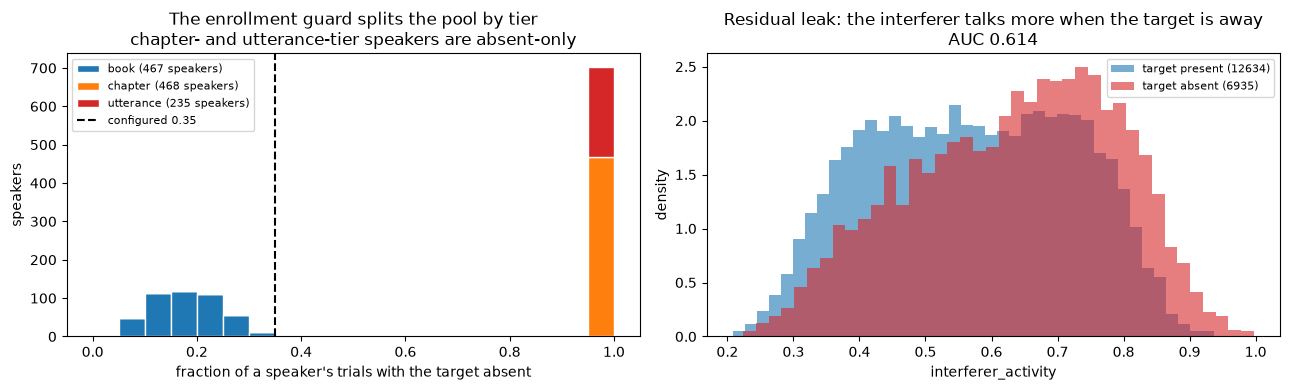

In [126]:
# Left: the same speaker-pool split as 7.4, but by B10's three guard tiers
# instead of the one-book/two-book binary. A speaker sitting at 1.0 is absent in
# every trial they appear in. Only `book`-tier speakers reach the present pool,
# so the other two pile up at 1.0 -- which is the leak, drawn.
tier_avail = strongest_tier_available(D.utts)
usage = D.df.groupby("target_speaker")["target_absent"].agg(["mean", "size"])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

bins = np.linspace(0, 1, 21)
groups, labels, colours = [], [], []
for t in TIERS:
    members = tier_avail[tier_avail == t].index
    v = usage.loc[usage.index.isin(members), "mean"]
    groups.append(v)
    labels.append(f"{t} ({len(v)} speakers)")
    colours.append(TIER_COLOUR[t])
ax1.hist(groups, bins=bins, stacked=True, edgecolor="white",
         color=colours, label=labels)
ax1.axvline(D.cfg["target_absent_fraction"], color="black", linestyle="--",
            label=f"configured {D.cfg['target_absent_fraction']}")
ax1.set_xlabel("fraction of a speaker's trials with the target absent")
ax1.set_ylabel("speakers")
ax1.set_title("The enrollment guard splits the pool by tier\n"
              "chapter- and utterance-tier speakers are absent-only")
ax1.legend(fontsize=8)

ax2.hist(present["interferer_activity"], bins=40, alpha=0.6, density=True,
         color="tab:blue", label=f"target present ({len(present)})")
ax2.hist(absent["interferer_activity"], bins=40, alpha=0.6, density=True,
         color="tab:red", label=f"target absent ({len(absent)})")
ax2.set_xlabel("interferer_activity")
ax2.set_ylabel("density")
ax2.set_title("Residual leak: the interferer talks more when the target is away\n"
              f"AUC {auc((D.df['target_absent'] == 1).astype(int), D.df['interferer_activity']):.3f}")
ax2.legend(fontsize=8)

plt.tight_layout()
plt.show()


**AUC 0.795 from the identity of the enrolled speaker alone.** No part of the mixture is consulted to compute that number. The interferer's identity says nothing (0.502), so this is specifically about the voice the model is told to listen for.

The cause is exact, not statistical. The present branch needs the target to own a second book, because the enrollment must come from a different book (`decisions.md` 2026-08-11). The absent branch skips `pick_run` and needs no such thing. When the retry loop draws a one-book speaker it silently redraws — so **the 467 speakers with two or more books are precisely the 467 that ever appear as a present target**, and the other 703 appear only in absent trials, 21.3% of the split. The left panel shows two disjoint populations with nothing between them.

The 2026-08-11 entry asked for exactly this check, and predicted single-book speakers would "yield no valid present trial". What actually happened is worse than dropping out: they were reassigned to absent-only, at 5.9 trials each against 33.0 for the two-book speakers, which turned a coverage cost into a label leak.

Why it matters for training rather than for reporting: the eval splits are speaker-disjoint and carry no absent trials, so no reported number is contaminated. But 35% of every training batch can have its silence decision made by voice recognition instead of by listening, and the push-to-silence term — the one thing absent trials exist to teach — is the term that stops being trained.

Cheapest fix, and the one recommended in `decisions-pending.md` B9: **draw the target speaker for absent trials from the two-book pool as well.** It costs nothing in realism, since the enrollment guard is about content leakage and an absent trial has no target content to leak. It leaves `interferer_activity` at 0.614, which is a separate and much smaller problem.

**Update, `decisions.md` 2026-08-13.** That fix was superseded before it was built.
Drawing absent targets from the two-book pool would have closed this leak but kept
703 of 1,172 speakers out of the present pool entirely — a coverage cost paid
silently. **B10 attacks the cause instead: the enrollment guard falls back through
three tiers rather than redrawing, and the tier is recorded per trial.** Every
speaker can then be a present target, and the price is a *measurable* weaker guard
on some of them instead of an invisible bias on all of them. 7.5 works through what
that looks like, and what the pool looks like just before it lands.


#### 7.5  The enrollment guard, and why B10 replaced it with three tiers

7.4 found the leak. This is the fix decided for it, and what the data looks like
in the moment before that fix lands.

The rule today is B8's: **the enrollment must come from a different book**, with no
fallback. A speaker who only ever recorded one book cannot satisfy it, so `pick_run`
redraws and that speaker never becomes a present target — which is exactly how a
coverage cost turned into the 0.795 label leak above.

`decisions.md` 2026-08-13 (**B10**) replaces the single rule with three tiers,
strongest first, and **records which one each trial got**:

| tier | enrollment comes from | why it is weaker |
|---|---|---|
| `book` | a different book | nothing shared but the voice |
| `chapter` | same book, different chapter | shares narrative, characters, proper nouns, register |
| `utterance` | same chapter, different utterance | all of the above, plus the immediate context |

A weaker tier is worse than a strong one, but it is **not** worse than the speaker
silently vanishing from the present pool — because the vanishing is what leaks. B10
trades a hidden, unmeasurable bias for a recorded, reportable one, which is the same
trade B13 makes everywhere else.

**None of this is in the data yet.** B10 folds into the PR3 rebuild, so
`enrollment_guard` is derived below rather than read, and every present trial still
comes out `book`. That constant is the finding, not a fault in the derivation.

The variety B10 is about lives in the **speaker pool**, and the two panels below show
it: which tier each speaker *could* support, and which speakers actually get used as
a present target today.


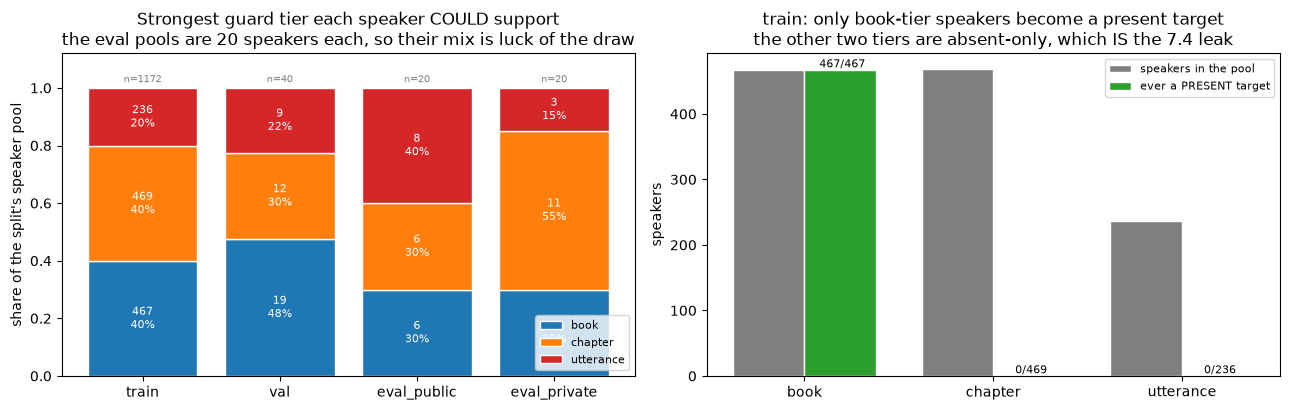

train: guard tier on present trials -> {'book': 12634}   (derived)
  pool tier book         467 speakers,   467 ever present (100%)
  pool tier chapter      469 speakers,     0 ever present (0%)
  pool tier utterance    236 speakers,     0 ever present (0%)


In [127]:
# Which guard tier each speaker COULD support, per split pool, against which
# speakers actually appear as a present target today.
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.2))

pools, labels = [], []
for name in ["train", "val", "eval_public", "eval_private"]:
    f = ROOT / "data/index" / f"utterances_{name}.csv"
    if not f.exists():
        continue
    u = pd.read_csv(f, dtype={"speaker": str, "chapter": str})
    pools.append(strongest_tier_available(u))
    labels.append(name)

bottom = np.zeros(len(pools))
for tier in TIERS:
    share = np.array([(p == tier).mean() for p in pools])
    ax1.bar(labels, share, bottom=bottom, color=TIER_COLOUR[tier],
            edgecolor="white", label=tier)
    for x, (sh, b, p) in enumerate(zip(share, bottom, pools)):
        if sh > 0.05:
            ax1.text(x, b + sh / 2, f"{(p == tier).sum()}\n{sh:.0%}", ha="center",
                     va="center", color="white", fontsize=8)
    bottom += share
for x, p in enumerate(pools):
    ax1.text(x, 1.02, f"n={len(p)}", ha="center", fontsize=7, color="grey")
ax1.set_ylim(0, 1.12)
ax1.set_ylabel("share of the split's speaker pool")
ax1.set_title("Strongest guard tier each speaker COULD support\n"
              "the eval pools are 20 speakers each, so their mix is luck of the draw")
ax1.legend(fontsize=8, loc="lower right")

tier_avail = strongest_tier_available(D.utts)
ever_present_now = set(D.df.loc[D.df["target_absent"] == 0, "target_speaker"])
used = pd.Series({s: (s in ever_present_now) for s in tier_avail.index})
xs = np.arange(len(TIERS))
w = 0.38
ax2.bar(xs - w/2, [(tier_avail == t).sum() for t in TIERS], w,
        color="tab:grey", edgecolor="white", label="speakers in the pool")
ax2.bar(xs + w/2, [((tier_avail == t) & used).sum() for t in TIERS], w,
        color="tab:green", edgecolor="white", label="ever a PRESENT target")
for x, t in zip(xs, TIERS):
    n_pool = int((tier_avail == t).sum())
    n_used = int(((tier_avail == t) & used).sum())
    ax2.text(x + w/2, n_used, f" {n_used}/{n_pool}", ha="center", va="bottom",
             fontsize=8)
ax2.set_xticks(xs)
ax2.set_xticklabels(TIERS)
ax2.set_ylabel("speakers")
ax2.set_title(f"{D.split}: only book-tier speakers become a present target\n"
              "the other two tiers are absent-only, which IS the 7.4 leak")
ax2.legend(fontsize=8)

plt.tight_layout()
plt.show()

guard = D.df.loc[D.df["target_absent"] == 0, "enrollment_guard"]
print(f"{D.split}: guard tier on present trials -> {guard.value_counts().to_dict()}"
      f"   ({'derived' if D.df['enrollment_guard_derived'].all() else 'from the manifest'})")
for t in TIERS:
    n_pool = int((tier_avail == t).sum())
    n_used = int(((tier_avail == t) & used).sum())
    pct = f"{n_used / n_pool:.0%}" if n_pool else "n/a"
    print(f"  pool tier {t:10} {n_pool:5} speakers, {n_used:5} ever present ({pct})")


### 8. Final variables check:
Considering the following variables: 
- `enrollment_eq` - is used to simulate a DIFFERENT enrollement device and borrowed as an idea from CARTSE
- `same_gender`

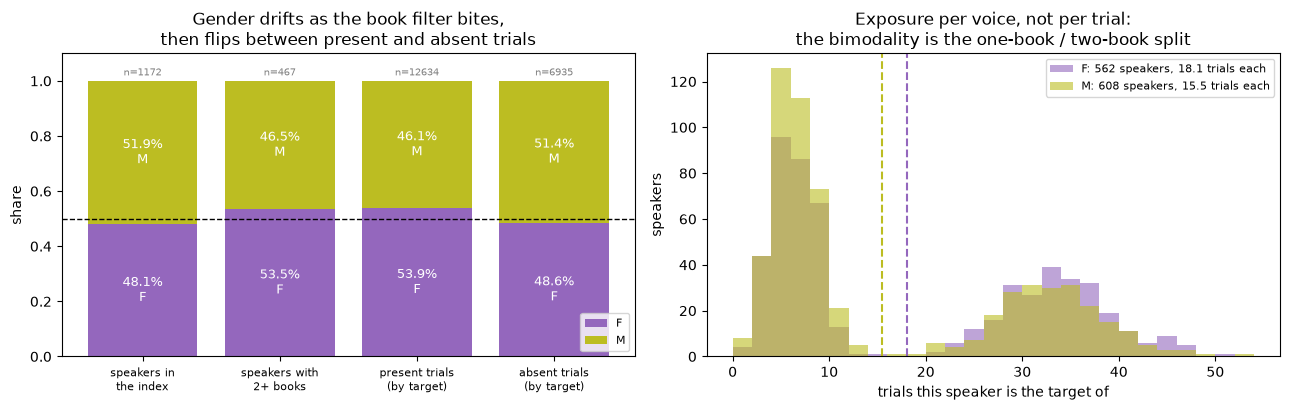

In [128]:

pool = pd.Series({s: sex[s] for s in D.utts["speaker"].unique().astype(str)})
books = D.utts.groupby("speaker")["chapter"].apply(lambda c:
c.map(book).nunique())
multi = set(books[books >= 2].index.astype(str))

stages = [
    ("speakers in\nthe index",      pool),
    ("speakers with\n2+ books",     pool[pool.index.isin(multi)]),
    ("present trials\n(by target)", present["target_speaker"].map(sex)),
    ("absent trials\n(by target)",  absent["target_speaker"].map(sex)),
]
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.2))
xs = np.arange(len(stages))
fshare = [(s == "F").mean() for _, s in stages]
ax1.bar(xs, fshare, color="tab:purple", label="F")
ax1.bar(xs, [1 - f for f in fshare], bottom=fshare, color="tab:olive", label="M")
ax1.axhline(0.5, color="black", linestyle="--", linewidth=1)
for x, f, (lab, s) in zip(xs, fshare, stages):
    ax1.text(x, f / 2, f"{f:.1%}\nF", ha="center", va="center", color="white", fontsize=9)
    ax1.text(x, f + (1 - f) / 2, f"{1-f:.1%}\nM", ha="center", va="center", color="white", fontsize=9)
    ax1.text(x, 1.02, f"n={len(s)}", ha="center", fontsize=7, color="grey")
ax1.set_xticks(xs); ax1.set_xticklabels([l for l, _ in stages], fontsize=8)
ax1.set_ylim(0, 1.10); ax1.set_ylabel("share")
ax1.set_title("Gender drifts as the book filter bites,\n"
            "then flips between present and absent trials")
ax1.legend(fontsize=8, loc="lower right")


# not "is it 50/50" but "does the model see each voice equally often"
usage = D.df.groupby("target_speaker").size()
gender = pd.Series({s: sex[s] for s in usage.index})
bins = np.arange(0, usage.max() + 3, 2)
for g, colour in [("F", "tab:purple"), ("M", "tab:olive")]:
    v = usage[gender == g]
    ax2.hist(v, bins=bins, alpha=0.6, color=colour,
            label=f"{g}: {len(v)} speakers, {v.mean():.1f} trials each")
    ax2.axvline(v.mean(), color=colour, linestyle="--")
ax2.set_xlabel("trials this speaker is the target of")
ax2.set_ylabel("speakers")
ax2.set_title("Exposure per voice, not per trial:\n"
            "the bimodality is the one-book / two-book split")
ax2.legend(fontsize=8)
plt.tight_layout()
plt.show()


### 9. Regimes (B12)

One regime is drawn **per trial**, and every regime-scoped parameter for that
trial then comes from that regime's bands. Drawn once per trial rather than once
per parameter: with six parameters chosen independently, an all-base trial would
occur in ~1.6 % of rows and the base condition would barely exist.

`hard` inherits `defaults` wholesale, so **`base` is a sub-range of `hard`** and
the column records **provenance, not difficulty**. Two consequences, both checked
below:

- **`regime` must not be a B13 reporting stratum.** Base and hard overlap, so
  comparing them would understate the gap. Report on value bands instead.
- **The leak audit must run *within* each regime**, not only pooled — a shortcut
  inside `base` can be diluted to invisibility in a combined AUC.

The eval splits set `regimes: null`, so they draw every parameter independently
from the wide ranges and record `none`. Under regimes a `hard` trial draws a wide
SIR *and* a wide overlap together, which correlates them; B13's per-condition
tables would then report one effect twice.

`regime` is renderer metadata. The model receives the mixture and the enrollment,
nothing else, so the column cannot become a shortcut.

`decisions.md` 2026-08-13 and 2026-08-14.


In [129]:
# What each regime actually drew, against the bands it was given.
if D.regimes is None:
    print(f"{D.split}: no regimes declared -- every row records 'none'.")
    print(f"  regime values present: {sorted(D.df['regime'].unique())}")
else:
    weights = D.regimes["weights"]
    total = sum(weights.values())
    print(f"{D.split}: {len(D.df)} trials")
    for name in sorted(weights):
        sub = D.df[D.df["regime"] == name]
        print(f"\n  {name}: {len(sub)} trials, {len(sub)/len(D.df):.3f} "
              f"(configured {weights[name]/total:.3f})")
        bands = resolve(D.sampling_cfg, name)
        # source_distance_m is sampled but only its coordinates are stored.
        sub = sub.copy()
        sub["source_distance_m"] = np.sqrt(
            (sub["target_x"] - sub["mic_x"])**2 + (sub["target_y"] - sub["mic_y"])**2)
        for key in REGIME_SCOPED:
            band = bands[key]
            col = {"overlap_ratio": "overlap_requested"}.get(key, key)
            if col not in sub.columns or not isinstance(band, list):
                print(f"      {key:22} {band}   (not a manifest column)")
                continue
            v = sub[col][sub["target_absent"] == 0] if col == "overlap_requested" else sub[col]
            v = v.dropna()
            if v.empty:
                continue
            inside = ((v >= band[0] - 1e-6) & (v <= band[1] + 1e-6)).mean()
            print(f"      {key:22} band {str(band):16} observed "
                  f"{v.min():7.3f}..{v.max():7.3f}   inside {inside:.1%}")


train: 19569 trials

  base: 11679 trials, 0.597 (configured 0.600)
      sir_db                 band [0.0, 12.0]      observed   0.000.. 12.000   inside 100.0%
      snr_db                 band [8.0, 20.0]      observed   8.000.. 20.000   inside 100.0%
      overlap_ratio          band [0.2, 0.7]       observed   0.200..  0.700   inside 100.0%
      t60_s                  band [0.25, 0.5]      observed   0.250..  0.500   inside 100.0%
      source_distance_m      band [0.66, 1.4]      observed   0.660..  1.400   inside 99.9%
      target_activity_ratio  0.75   (not a manifest column)

  hard: 7890 trials, 0.403 (configured 0.400)
      sir_db                 band [-5.0, 15.0]     observed  -4.990.. 15.000   inside 100.0%
      snr_db                 band [0.0, 20.0]      observed   0.010.. 20.000   inside 100.0%
      overlap_ratio          band [0.2, 0.7]       observed   0.200..  0.700   inside 100.0%
      t60_s                  band [0.25, 0.6]      observed   0.250..  0.600   ins

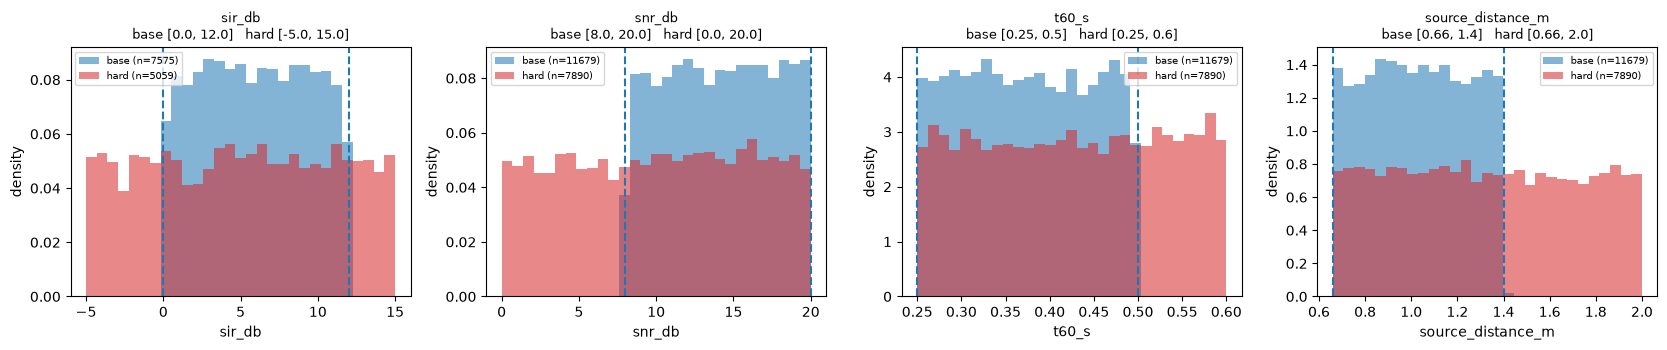

Dashed lines are the `base` band. `base` is flat inside it and absent
outside; `hard` is flat across the whole width, so it overlaps `base`
everywhere the two share. That overlap is why the regime column is
provenance and not a difficulty stratum -- quantified next.


In [130]:
# What the two regimes actually look like, per narrowed parameter.
if D.regimes is None:
    print(f"{D.split}: no regimes declared -- nothing to plot.")
else:
    base_bands = resolve(D.sampling_cfg, "base")
    hard_bands = resolve(D.sampling_cfg, "hard")
    COL = {"overlap_ratio": "overlap_requested"}

    dfx = D.df.copy()
    dfx["source_distance_m"] = np.sqrt(
        (dfx["target_x"] - dfx["mic_x"])**2 + (dfx["target_y"] - dfx["mic_y"])**2)

    keys = [k for k in REGIME_SCOPED
            if isinstance(base_bands[k], list)
            and base_bands[k] != hard_bands[k]
            and COL.get(k, k) in dfx.columns]

    fig, axes = plt.subplots(1, len(keys), figsize=(4.2 * len(keys), 3.6))
    axes = np.atleast_1d(axes)
    for ax, key in zip(axes, keys):
        col = COL.get(key, key)
        wide = hard_bands[key]
        bins = np.linspace(wide[0], wide[1], 30)
        for name, colour in (("base", "tab:blue"), ("hard", "tab:red")):
            v = dfx.loc[dfx["regime"] == name, col].dropna()
            ax.hist(v, bins=bins, alpha=0.55, density=True, color=colour,
                    label=f"{name} (n={len(v)})")
        for edge in base_bands[key]:
            ax.axvline(edge, color="tab:blue", linestyle="--", linewidth=1.5)
        ax.set_xlabel(key)
        ax.set_ylabel("density")
        ax.set_title(f"{key}\nbase {base_bands[key]}   hard {wide}", fontsize=9)
        ax.legend(fontsize=7)
    plt.tight_layout()
    plt.show()

    print("Dashed lines are the `base` band. `base` is flat inside it and absent")
    print("outside; `hard` is flat across the whole width, so it overlaps `base`")
    print("everywhere the two share. That overlap is why the regime column is")
    print("provenance and not a difficulty stratum -- quantified next.")


In [131]:
# Why `regime` is provenance and not difficulty: how often does a `hard` draw
# land inside the `base` band anyway? If that number is high, the two regimes
# describe overlapping populations, and reporting them as a B13 stratum would
# understate the gap rather than measure it.
if D.regimes is not None and "base" in D.regimes.get("weights", {}):
    base_bands = resolve(D.sampling_cfg, "base")
    hard_bands = resolve(D.sampling_cfg, "hard")
    hard = D.df[D.df["regime"] == "hard"].copy()

    # source_distance_m is sampled but never stored as a column -- only the
    # coordinates it produced are. Recover it, or one of the four narrowed
    # parameters would be silently dropped from this statistic.
    hard["source_distance_m"] = np.sqrt(
        (hard["target_x"] - hard["mic_x"])**2 + (hard["target_y"] - hard["mic_y"])**2)
    COL = {"overlap_ratio": "overlap_requested"}

    narrowed = [k for k in REGIME_SCOPED
                if isinstance(base_bands[k], list)
                and base_bands[k] != hard_bands[k]
                and COL.get(k, k) in hard.columns]

    inside_all = pd.Series(True, index=hard.index)
    print(f"{D.split}: {len(hard)} 'hard' trials, "
          f"{len(narrowed)} parameters narrowed by 'base'\n")
    print("a 'hard' trial lands inside the 'base' band ...")
    for key in narrowed:
        lo, hi = base_bands[key]
        v = hard[COL.get(key, key)]
        within = ((v >= lo - 1e-6) & (v <= hi + 1e-6)).fillna(False)
        inside_all &= within
        print(f"  {key:22} [{lo}, {hi}]   {within.mean():.1%} of the time")
    print(f"\n  inside ALL {len(narrowed)} narrowed bands at once: "
          f"{inside_all.mean():.1%} of hard trials")
    print("\nThat is why the column records provenance, not difficulty -- and why")
    print("filtering regime == base is the supported way to make training easier,")
    print("while reporting base against hard as a B13 stratum is not.")
else:
    print(f"{D.split}: no regimes declared, so there is nothing to compare.")


train: 7890 'hard' trials, 4 parameters narrowed by 'base'

a 'hard' trial lands inside the 'base' band ...
  sir_db                 [0.0, 12.0]   38.6% of the time
  snr_db                 [8.0, 20.0]   61.6% of the time
  t60_s                  [0.25, 0.5]   70.3% of the time
  source_distance_m      [0.66, 1.4]   56.2% of the time

  inside ALL 4 narrowed bands at once: 9.2% of hard trials

That is why the column records provenance, not difficulty -- and why
filtering regime == base is the supported way to make training easier,
while reporting base against hard as a B13 stratum is not.


## Final healthchecks

`check(D)` gathers **every condition asserted anywhere above** into one place, so
a rebuild can be verified without re-reading the notebook. `check_across_splits()`
covers the conditions that are about the *relationship between* splits and cannot
be seen from one manifest.

Two outcomes are distinguished on purpose:

- **FAIL** — an invariant the generator must satisfy. A failure is a bug.
- **WARN** — a known open decision that is true of the data today. Each names the
  decision that will close it (B9, B10). These are listed so they cannot be
  quietly forgotten, but they are not counted as failures.


In [132]:
# Every condition asserted anywhere above, gathered into one function.
# Section tags in brackets say where each one is explained and why it matters.
#
# Three outcomes, not two:
#   PASS/FAIL  an invariant the generator must satisfy. A FAIL is a bug.
#   WARN       a known open decision, true of the data today. Listed so it
#              cannot be forgotten, not counted as a failure. Each names the
#              decision that will close it.

_LS = ROOT / "data/librispeech/LibriSpeech"


def _librispeech_maps():
    """{speaker: sex}, {chapter: book} from the corpus metadata."""
    sex, book = {}, {}
    for line in (_LS / "SPEAKERS.TXT").read_text(errors="replace").splitlines():
        if not line.lstrip().startswith(";") and line.strip():
            f = [p.strip() for p in line.split("|")]
            sex[f[0]] = f[1]
    for line in (_LS / "CHAPTERS.TXT").read_text(errors="replace").splitlines():
        if not line.lstrip().startswith(";") and line.strip():
            f = [p.strip() for p in line.split("|")]
            book[f[0]] = f[5]
    return sex, book


def _intended_absent(trial_id, fraction):
    """Replay the generator's absent coin-flip from the trial id alone.

    The `aug` stream is child 3. build_manifest.py now spawns FIVE children
    rather than four (the fifth draws the regime), but SeedSequence.spawn(n)
    is deterministic per index -- spawn(5)[3] is the same stream as
    spawn(4)[3] -- so this replay is unaffected by that change. [7.2]
    """
    digest = hashlib.blake2b(trial_id.encode(), digest_size=8).digest()
    seeds = np.random.SeedSequence(int.from_bytes(digest, "big")).spawn(5)
    return float(np.random.default_rng(seeds[3]).random()) < fraction


def auc(y, score):
    """AUC of a one-column classifier. 0.5 says nothing, 1.0 gives it away.
    Mann-Whitney identity, written out to keep the notebook numpy-only. [7.3]"""
    good = pd.notna(score)
    y, score = np.asarray(y)[good], pd.Series(score)[good].rank().to_numpy()
    n_pos, n_neg = y.sum(), len(y) - y.sum()
    if n_pos == 0 or n_neg == 0:
        return float("nan")
    return (score[y == 1].sum() - n_pos * (n_pos + 1) / 2) / (n_pos * n_neg)


def check(D, leak_ceiling=0.75):
    df = D.df
    present = df[df["target_absent"] == 0]
    absent = df[df["target_absent"] == 1]
    sex, book = _librispeech_maps()

    fails, warns = [], []

    def ok(name, passed, detail=""):
        passed = bool(passed)
        print(f"  {'PASS' if passed else 'FAIL'}  {name:<52} {detail}")
        if not passed:
            fails.append(name)

    def warn(name, quiet, detail=""):
        quiet = bool(quiet)
        print(f"  {'ok  ' if quiet else 'WARN'}  {name:<52} {detail}")
        if not quiet:
            warns.append(name)

    print(f"{D.split}: {len(df)} trials, {len(present)} present, "
          f"{len(absent)} absent, {len(D.columns)} columns")
    print(f"  built {D.meta['generated']}  commit {D.meta['git_commit'][:7]}  "
          f"config {'CHANGED SINCE BUILD' if D.config_stale else 'unchanged'}")
    if D.config_stale:
        # Without this banner a stale manifest produces a wall of range
        # failures that look like generator bugs. They are not: the manifest
        # was built by a different config than the one it is being checked
        # against. Say so once, loudly, before any of them print.
        print("\n  " + "!" * 68)
        print("  !! This manifest was built from a DIFFERENT config than the one on")
        print("  !! disk now, so the checks below compare it against ranges it was")
        print("  !! never sampled from. Failures here are stale data, not bugs.")
        print(f"  !!   rebuild:  python scripts/build_manifest.py --split {D.split}")
        print("  " + "!" * 68)

    # ---- schema -----------------------------------------------------[0]
    print("\n  schema")
    ok("regime column present", "regime" in df.columns)
    ok("no missing values outside the absent-only columns",
       not df.drop(columns=[c for c in ["target_chapter", "target_utts",
                                        "target_onsets_s", "sir_db"]
                            if c in df.columns]).isna().any().any())

    # ---- identity and pairing ---------------------------------[1, 5, 7.1]
    print("\n  identity and pairing")
    ok("trial_ids unique", df["trial_id"].is_unique)
    ok("target never equals interferer",
       (df["target_speaker"] != df["interferer_speaker"]).all())
    enroll_spk = df["enrollment_utt"].str.split("-").str[0]
    ok("enrollment speaker is the target", (enroll_spk == df["target_speaker"]).all())
    ok("enrollment is never the interferer",
       not (enroll_spk == df["interferer_speaker"]).any())
    ok("same_gender flag matches SPEAKERS.TXT",
       (df["same_gender"] == (df["target_speaker"].map(sex)
                              == df["interferer_speaker"].map(sex)).astype(int)).all())

    enroll_ch = present["enrollment_utt"].str.split("-").str[1]
    tgt_book = present["target_chapter"].map(book)
    ok("enrollment chapter differs from the mixture chapter",
       (enroll_ch != present["target_chapter"]).all())
    ok("enrollment BOOK differs from the target book (B8)",
       (enroll_ch.map(book) != tgt_book).all(),
       f"{int((enroll_ch.map(book) == tgt_book).sum())} violations")
    ok("interferer book differs from the target book",
       (present["interferer_chapter"].map(book) != tgt_book).all())

    # B10 enrollment guard tier. Today every present trial is `book`, because
    # B8 hard-requires a different book and silently redraws any speaker who
    # cannot supply one -- which is precisely the leak 7.4 measures. PR3 records
    # the tier and permits the weaker two, at which point this stops being
    # constant and the per-tier scoreboard below starts saying something.
    guard = df.loc[df["target_absent"] == 0, "enrollment_guard"]
    ok("enrollment guard tier is one of book/chapter/utterance",
       set(guard) <= set(TIERS),
       f"{guard.value_counts().to_dict()}"
       + ("  (derived; PR3 records it)" if df["enrollment_guard_derived"].all() else ""))
    ok("enrollment utterance is never one of the mixture utterances",
       not df.apply(lambda r: r["enrollment_utt"] in r["target_utt_list"], axis=1).any())

    if D.utts is not None:
        edur = df["enrollment_utt"].map(D.utts["duration"].to_dict())
        ok("enrollment window fits inside its clip",
           ((df["enrollment_offset_s"] + df["enrollment_length_s"])
            <= edur + 1e-6).all())
        ok("enrollment clips are at least 5 s (metric minimum)",
           (edur >= 5.0 - 1e-6).all(), f"shortest {edur.min():.2f} s")

    # ---- timing and overlap ------------------------------------------[2]
    print("\n  timing and overlap")
    d = (present["target_activity"]
         - present["target_speech_s"] / present["mixture_length_s"]).abs()
    ok("activity == speech_s / length", d.max() < 1e-3, f"worst {d.max():.1e}")
    d = (present["target_speech_s"] - present["target_dur_list"].map(sum)).abs()
    ok("speech_s == sum(utterance durations)", d.max() < 1e-3, f"worst {d.max():.1e}")

    worst_ov, worst_end, unsorted_, negative = 0.0, -9.9, 0, 0
    for _, row in df.iterrows():
        shared = 0.0
        for t0, t1 in spans(row, "target"):
            for i0, i1 in spans(row, "interferer"):
                shared += max(0.0, min(t1, i1) - max(t0, i0))
        worst_ov = max(worst_ov,
                       abs(shared / row["mixture_length_s"] - row["overlap_achieved"]))
        ends = [e for who in ("target", "interferer") for _, e in spans(row, who)]
        worst_end = max(worst_end, max(ends) - row["mixture_length_s"])
        for who in ("target", "interferer"):
            ons = row[f"{who}_onset_list"]
            unsorted_ += ons != sorted(ons)
            negative += any(o < 0 for o in ons)
    ok("overlap_achieved recomputes from the spans", worst_ov < 1e-3,
       f"worst {worst_ov:.1e}")
    ok("onsets are sorted", unsorted_ == 0)
    ok("no negative onsets", negative == 0)
    # 1 ms, not 1 us: onsets are rounded to 4 dp in the CSV.
    ok("no source runs past the window", worst_end < 1e-3,
       f"worst overshoot {worst_end*1000:+.3f} ms")
    miss = (present["overlap_achieved"] - present["overlap_requested"]).abs()
    ok("overlap miss within tolerance",
       miss.max() <= D.cfg["overlap_tolerance"] + 1e-9,
       f"worst {miss.max():.4f} of {D.cfg['overlap_tolerance']}")

    # ---- sampled ranges, globally and per regime -------------------[3, 9]
    print("\n  sampled ranges (global config bands)")
    for col, key in RANGES.items():
        lo, hi = D.cfg[key]
        v = df[col][df["target_absent"] == 0] if col == "overlap_requested" else df[col]
        v = v.dropna()
        ok(f"{col} within [{lo}, {hi}]",
           ((v >= lo - 1e-6) & (v <= hi + 1e-6)).all(),
           f"observed {v.min():.3f}..{v.max():.3f}, covers {(v.max()-v.min())/(hi-lo):.0%}")

    print("\n  sampled ranges (per regime -- the stronger check)")
    for reg in sorted(df["regime"].unique()):
        bands = resolve(D.sampling_cfg, None if reg == "none" else reg)
        sub = df[df["regime"] == reg]
        for col, key in RANGES.items():
            band = bands[key]
            if not isinstance(band, list):
                continue
            lo, hi = band
            v = sub[col][sub["target_absent"] == 0] if col == "overlap_requested" else sub[col]
            v = v.dropna()
            if v.empty:
                continue
            ok(f"[{reg}] {col} within [{lo}, {hi}]",
               ((v >= lo - 1e-6) & (v <= hi + 1e-6)).all(),
               f"observed {v.min():.3f}..{v.max():.3f}")

    # ---- regimes ------------------------------------------------------[9]
    print("\n  regimes")
    allowed = {"none"} | set((D.regimes or {}).get("weights", {}))
    ok("regime values are all declared in the config",
       set(df["regime"]) <= allowed, f"{sorted(set(df['regime']))}")
    if D.regimes is None:
        ok("split declares no regimes, so every row records 'none'",
           (df["regime"] == "none").all())
    else:
        weights = D.regimes["weights"]
        total = sum(weights.values())
        # 4 sigma on a binomial: a mix this far off means the draw is wrong,
        # not unlucky. Widened automatically for small splits.
        for name, w in sorted(weights.items()):
            want = w / total
            got = (df["regime"] == name).mean()
            tol = max(0.02, 4 * math.sqrt(want * (1 - want) / len(df)))
            ok(f"regime '{name}' share is {want:.2f}", abs(got - want) <= tol,
               f"got {got:.3f} (tolerance {tol:.3f})")
        ok("no row records 'none' in a split that has regimes",
           not (df["regime"] == "none").any())

    # ---- room and geometry -------------------------------------------[4]
    print("\n  room and geometry")
    lo, hi = D.cfg["source_distance_m"]
    for who in ("target", "interferer"):
        dist = np.sqrt((df[f"{who}_x"] - df["mic_x"])**2
                       + (df[f"{who}_y"] - df["mic_y"])**2)
        wall = pd.concat([df[f"{who}_x"], df["room_l"] - df[f"{who}_x"],
                          df[f"{who}_y"], df["room_w"] - df[f"{who}_y"]],
                         axis=1).min(axis=1)
        ok(f"{who} distance in [{lo}, {hi}]",
           ((dist >= lo - 0.01) & (dist <= hi + 0.01)).all(),
           f"{dist.min():.2f}..{dist.max():.2f} m")
        # 1e-6 fudge: the generator can place a source at exactly 0.3 m and
        # the float round-trip through the CSV then lands just under.
        ok(f"{who} clears every wall by 0.3 m", (wall >= 0.3 - 1e-6).all(),
           f"min {wall.min():.3f} m")
        ok(f"{who} is below the ceiling", (df[f"{who}_z"] < df["room_h"]).all())

    # source_distance_m is regime-scoped but is never stored as a column --
    # only the coordinates it produced are. Recovered here, or the base
    # narrowing of this one parameter would never actually be verified.
    for reg in sorted(df["regime"].unique()):
        band = resolve(D.sampling_cfg, None if reg == "none" else reg)["source_distance_m"]
        sub = df[df["regime"] == reg]
        for who in ("target", "interferer"):
            dd = np.sqrt((sub[f"{who}_x"] - sub["mic_x"])**2
                         + (sub[f"{who}_y"] - sub["mic_y"])**2)
            ok(f"[{reg}] {who} distance in [{band[0]}, {band[1]}]",
               ((dd >= band[0] - 0.01) & (dd <= band[1] + 0.01)).all(),
               f"{dd.min():.2f}..{dd.max():.2f} m")

    # 1e-3, not 1e-6: mic_x and room_l are each stored to 3 decimals, so their
    # ratio can sit ~5e-5 outside the band on rounding alone (worst measured on
    # train: 4.5e-5). The tolerance still catches a mic placed against a wall.
    for axis, room in (("mic_x", "room_l"), ("mic_y", "room_w")):
        frac = df[axis] / df[room]
        ok(f"{axis} sits 0.35-0.65 across the room",
           ((frac >= 0.35 - 1e-3) & (frac <= 0.65 + 1e-3)).all(),
           f"{frac.min():.4f}..{frac.max():.4f}")

    vol = df["room_l"] * df["room_w"] * df["room_h"]
    surf = 2 * (df["room_l"]*df["room_w"] + df["room_l"]*df["room_h"]
                + df["room_w"]*df["room_h"])
    # Sabine (1922) at alpha = 1: the shortest T60 the room could physically
    # have. The same relation pra.inverse_sabine inverts in build_manifest.py.
    ok("t60 reachable in its room (Sabine floor)",
       (df["t60_s"] >= 0.161 * vol / surf).all(),
       f"{int((df['t60_s'] < 0.161 * vol / surf).sum())} below the floor")
    # sample_room redraws the WHOLE room on an infeasible draw, so t60 and
    # volume must stay uncorrelated. A correlation here is rejection bias.
    r = float(np.corrcoef(df["t60_s"], vol)[0, 1])
    floor = 2 / math.sqrt(len(df))
    ok("t60 uncorrelated with room volume (no rejection bias)",
       abs(r) <= floor, f"r = {r:+.3f}, noise floor {floor:.3f}")

    # ---- noise --------------------------------------------------------[6]
    print("\n  noise")
    if D.noise is not None:
        ok(f"every noise clip exists in the '{D.cfg['noise_split']}' index",
           not (set(df["noise_clip"]) - set(D.noise.index)),
           f"{len(set(df['noise_clip']) - set(D.noise.index))} missing")
        clipdur = df["noise_clip"].map(D.noise["duration"].to_dict())
        ok("noise offset lands inside its clip",
           ((df["noise_offset_s"] >= 0) & (df["noise_offset_s"] <= clipdur)).all())
        wraps = (clipdur - df["noise_offset_s"]) < df["mixture_length_s"]
        warn("noise bed wraps within the mixture", not wraps.any(),
             f"{int(wraps.sum())}/{len(df)} trials wrap -- audible seam, "
             f"accepted by the wrap decision [6]")

    # ---- target-absent trials ---------------------------------------[7]
    print("\n  target-absent trials")
    ok("sir_db null exactly when the target is absent",
       (df["sir_db"].isna() == (df["target_absent"] == 1)).all())
    for col in ("target_chapter", "target_utts", "target_onsets_s"):
        blank = absent[col].isna() | (absent[col].astype(str).str.strip() == "")
        ok(f"{col} empty on every absent row", blank.all() if len(absent) else True)
    for col in ("target_speech_s", "target_activity",
                "overlap_requested", "overlap_achieved"):
        ok(f"{col} is 0 on every absent row",
           (absent[col].abs() < 1e-9).all() if len(absent) else True)
    ok("absent rows still carry a target position",
       absent[["target_x", "target_y", "target_z"]].notna().all().all()
       if len(absent) else True)
    ok("absent rows still draw target_loudness_lufs",
       absent["target_loudness_lufs"].notna().all() if len(absent) else True)

    frac = D.cfg["target_absent_fraction"]
    replay = df["trial_id"].map(lambda t: _intended_absent(t, frac)).astype(int)
    ok("absent flag replays from the trial id and seed",
       (replay == df["target_absent"]).all(),
       f"{int((replay != df['target_absent']).sum())} disagree")
    rate = (df["target_absent"] == 1).mean()
    warn("absent rate matches the configured fraction",
         abs(rate - frac) < 0.03 or len(df) < 100,
         f"asked {frac:.2f}, got {rate:.3f}")

    # ---- leak scoreboard, pooled AND per regime --------------[7.3, 7.4, 9]
    # Per regime as well as pooled: a shortcut inside one regime can be
    # diluted to invisibility in a combined AUC. decisions.md 2026-08-13.
    print("\n  leak scoreboard (WARN = a known open decision, not a bug)")
    leak_cols = ["interferer_activity", "interferer_speech_s", "mixture_length_s",
                 "snr_db", "target_loudness_lufs", "t60_s", "room_l", "room_h",
                 "enrollment_offset_s", "noise_offset_s", "same_gender",
                 "enrollment_eq"]
    scopes = [("pooled", df)] + ([] if D.regimes is None else
                                 [(r, df[df["regime"] == r])
                                  for r in sorted(df["regime"].unique())])
    for label, sub in scopes:
        y = (sub["target_absent"] == 1).astype(int)
        if y.nunique() < 2:
            continue
        worst_col, worst_auc = None, 0.5
        for col in leak_cols:
            a = auc(y, sub[col])
            if not math.isnan(a) and abs(a - 0.5) > abs(worst_auc - 0.5):
                worst_col, worst_auc = col, a
        warn(f"[{label}] no column predicts absence above {leak_ceiling}",
             abs(worst_auc - 0.5) + 0.5 <= leak_ceiling,
             f"worst: {worst_col} AUC {worst_auc:.3f}   (B9 fixes this)")

    # Per guard tier as well as per regime: B10 exists because a weaker tier
    # leaks more, so the scoreboard has to be able to see that difference the
    # moment PR3 makes the tier vary.
    if guard.nunique() > 1:
        for tier in sorted(guard.unique()):
            sub = df[(df["target_absent"] == 1) | (df["enrollment_guard"] == tier)]
            y = (sub["target_absent"] == 1).astype(int)
            if y.nunique() < 2:
                continue
            a = auc(y, sub["interferer_activity"])
            warn(f"[guard={tier}] interferer_activity does not predict absence",
                 abs(a - 0.5) + 0.5 <= leak_ceiling, f"AUC {a:.3f}")
    elif len(guard):
        print(f"  --    guard tier is constant ('{guard.iloc[0]}'), so there is "
              f"nothing to compare across tiers yet [B10 lands in PR3]")

    if len(absent) and len(present):
        g = df.groupby("target_speaker")["target_absent"]
        prior = ((g.transform("sum") - df["target_absent"])
                 / (g.transform("size") - 1).replace(0, np.nan))
        a = auc((df["target_absent"] == 1).astype(int), prior)
        warn("enrolled speaker identity does not predict absence",
             abs(a - 0.5) + 0.5 <= leak_ceiling,
             f"AUC {a:.3f}   (B10 three-tier guard fixes this)")

    print(f"\n  {len(fails)} FAILED: {fails}" if fails else "\n  all checks passed")
    if warns:
        print(f"  {len(warns)} warning(s): {warns}")
    return fails, warns


In [133]:
def check_across_splits(splits=("train", "val", "eval_public", "eval_private")):
    """Conditions about the relationship BETWEEN splits. [5, 6]"""
    print("across splits")
    fails = []

    def ok(name, passed, detail=""):
        print(f"  {'PASS' if bool(passed) else 'FAIL'}  {name:<52} {detail}")
        if not passed:
            fails.append(name)

    loaded = {}
    for s in splits:
        try:
            loaded[s] = load(s)
        except FileNotFoundError:
            print(f"  skip  {s}: manifest not built")

    # Speakers must never cross between training and evaluation, or the eval
    # measures memorisation. [5]
    spk = {s: set(D.df["target_speaker"]) | set(D.df["interferer_speaker"])
           for s, D in loaded.items()}
    for tr in ("train", "val"):
        for ev in ("eval_public", "eval_private"):
            if tr in spk and ev in spk:
                ok(f"{tr} and {ev} share no speaker", not (spk[tr] & spk[ev]),
                   f"{len(spk[tr] & spk[ev])} shared")

    # Noise clips must never cross either, or the model hears the same bed in
    # training and in evaluation. [6]
    noi = {s: set(D.df["noise_clip"]) for s, D in loaded.items()}
    for tr in ("train", "val"):
        for ev in ("eval_public", "eval_private"):
            if tr in noi and ev in noi:
                ok(f"{tr} and {ev} share no noise clip", not (noi[tr] & noi[ev]),
                   f"{len(noi[tr] & noi[ev])} shared")

    # Every split must be built from the same config, or the numbers above are
    # not comparable across splits.
    md5s = {s: D.meta.get("config_md5") for s, D in loaded.items()}
    ok("every split built from the same config", len(set(md5s.values())) <= 1,
       f"{md5s}")

    # The eval splits must be the ones without regimes. [9]
    for ev in ("eval_public", "eval_private"):
        if ev in loaded:
            ok(f"{ev} declares no regimes", loaded[ev].regimes is None)
    for tr in ("train", "val"):
        if tr in loaded:
            ok(f"{tr} declares regimes", loaded[tr].regimes is not None)

    print(f"\n  {len(fails)} FAILED: {fails}" if fails else "\n  all checks passed")
    return fails


In [134]:
for split in ["smoke_train", "smoke_val", "val", "eval_public"]:
    check(load(split))
    print()

check_across_splits()


smoke_train: 50 trials, 36 present, 14 absent, 42 columns
  built 2026-08-14  commit 2df978e  config unchanged

  schema
  PASS  regime column present                                
  PASS  no missing values outside the absent-only columns    

  identity and pairing
  PASS  trial_ids unique                                     
  PASS  target never equals interferer                       
  PASS  enrollment speaker is the target                     
  PASS  enrollment is never the interferer                   
  PASS  same_gender flag matches SPEAKERS.TXT                
  PASS  enrollment chapter differs from the mixture chapter  
  PASS  enrollment BOOK differs from the target book (B8)    0 violations
  PASS  interferer book differs from the target book         
  PASS  enrollment guard tier is one of book/chapter/utterance {'book': 36}  (derived; PR3 records it)
  PASS  enrollment utterance is never one of the mixture utterances 
  PASS  enrollment window fits inside its clip     

[]